completeness for province

In [325]:
from pathlib import Path
from met_pipeline.io import load_excel, load_csv, normalize_kab_kota
from met_pipeline.quality import compute_entity_completeness

PROJECT_ROOT = Path.cwd().parent

df = load_excel(
    PROJECT_ROOT / "data" / "raw" / "master_timbulan_sipsn_new.xlsx",
    header=0,
)

ref_df = load_csv(
    PROJECT_ROOT / "data" / "reference" / "master_kab_reference_final.csv"
)


In [326]:
# Rename reference columns
ref_df = ref_df.rename(columns={
    "provinsi": "Provinsi",
    "kab_kota": "Kabupaten/Kota"
})

# Rename timbulan columns
df = df.rename(columns={
    "nama_provinsi": "Provinsi",
    "nama_kabkota": "Kabupaten/Kota",
    "tahun": "Tahun"
})

In [188]:
# Remove whitespace
for col in ["Provinsi", "Kabupaten/Kota"]:
    ref_df[col] = ref_df[col].str.strip()
    df[col] = df[col].str.strip()

In [327]:
df_valid = df[df["jml_timbulan_tahun"].notna()]

In [328]:
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab_Resmi")
)

In [329]:
reported = (
    df_valid.groupby(["Provinsi", "Tahun"])["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Kab_Melapor")
)

In [330]:
completeness = reported.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

completeness["Completeness"] = (
    completeness["Kab_Melapor"] /
    completeness["Total_Kab_Resmi"]
)

# Optional 0–10 scale
completeness["Score_0_10"] = completeness["Completeness"] * 10

In [331]:
completeness.sort_values(["Provinsi", "Tahun"]).head(20)

,Provinsi,Tahun,Kab_Melapor,Total_Kab_Resmi,Completeness,Score_0_10
0,Aceh,2019,1,23.0,0.043478,0.434783
1,Aceh,2020,6,23.0,0.260870,2.608696
2,Aceh,2021,2,23.0,0.086957,0.869565
3,Aceh,2022,8,23.0,0.347826,3.478261
4,Aceh,2023,13,23.0,0.565217,5.652174
5,Aceh,2024,23,23.0,1.000000,10.000000
6,Aceh,2025,21,23.0,0.913043,9.130435
7,Bali,2020,5,9.0,0.555556,5.555556
8,Bali,2021,4,9.0,0.444444,4.444444
9,Bali,2022,4,9.0,0.444444,4.444444


In [332]:
missing = set(df["Kabupaten/Kota"]) - set(ref_df["Kabupaten/Kota"])
print(len(missing))
print(list(missing)[:10])

5
['Kab. Pangkajene Kepulauan', 'Kota Pematang Siantar', 'Kota Padangsidimpuan', 'Kab. Timor Tengah Selatan', 'Kab. Pangkajene dan Kepulauan']


In [333]:
# Manual correction dictionary
name_corrections = {
    "Kab. Pangkajene Kepulauan": "Kab. Pangkajene dan Kepulauan",
    "Kota Pematang Siantar": "Kota Pematangsiantar",
    "Kota Padangsidimpuan": "Kota Padang Sidempuan",
}

# Apply corrections
df["Kabupaten/Kota"] = df["Kabupaten/Kota"].replace(name_corrections)

In [334]:
missing = set(df["Kabupaten/Kota"]) - set(ref_df["Kabupaten/Kota"])
print(len(missing))
print(missing)

2
{'Kab. Timor Tengah Selatan', 'Kab. Pangkajene dan Kepulauan'}


In [335]:
# Search reference for anything containing 'Pangkajene'
ref_df[ref_df["Kabupaten/Kota"].str.contains("Pangkajene", case=False)]

,Provinsi,Kabupaten/Kota
388,Sulawesi Selatan,Kab. Pangkajene Dan Kepulauan


In [336]:
ref_df[ref_df["Kabupaten/Kota"].str.contains("Timor", case=False)]

,Provinsi,Kabupaten/Kota
294,Nusa Tenggara Timur,Kab Timor Tengah Selatan
314,Nusa Tenggara Timur,Kab. Timor Tengah Utara


In [337]:
def clean_kab_name(x):
    x = x.strip()
    x = x.replace("Kabupaten", "Kab")
    x = x.replace("Kab.", "Kab")
    x = x.replace("Kota ", "Kota ")
    x = x.replace("Dan", "dan")
    x = x.replace("  ", " ")
    return x

ref_df["Kabupaten/Kota"] = ref_df["Kabupaten/Kota"].apply(clean_kab_name)
df["Kabupaten/Kota"] = df["Kabupaten/Kota"].apply(clean_kab_name)

In [338]:
missing = set(df["Kabupaten/Kota"]) - set(ref_df["Kabupaten/Kota"])
print(len(missing))
print(missing)

0
set()


In [339]:
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab_Resmi")
)

In [340]:
df_valid = df[df["jml_timbulan_tahun"].notna()]

In [341]:
reported = (
    df_valid.groupby(["Provinsi", "Tahun"])["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Kab_Melapor")
)

In [342]:
completeness = reported.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

In [343]:
completeness["Completeness"] = (
    completeness["Kab_Melapor"] /
    completeness["Total_Kab_Resmi"]
)

completeness["Score_0_10"] = completeness["Completeness"] * 10

In [344]:
completeness = completeness.sort_values(["Provinsi", "Tahun"])
completeness.head(20)

,Provinsi,Tahun,Kab_Melapor,Total_Kab_Resmi,Completeness,Score_0_10
0,Aceh,2019,1,23.0,0.043478,0.434783
1,Aceh,2020,6,23.0,0.260870,2.608696
2,Aceh,2021,2,23.0,0.086957,0.869565
3,Aceh,2022,8,23.0,0.347826,3.478261
4,Aceh,2023,13,23.0,0.565217,5.652174
5,Aceh,2024,23,23.0,1.000000,10.000000
6,Aceh,2025,21,23.0,0.913043,9.130435
7,Bali,2020,5,9.0,0.555556,5.555556
8,Bali,2021,4,9.0,0.444444,4.444444
9,Bali,2022,4,9.0,0.444444,4.444444


In [345]:
prov_summary = (
    completeness.groupby("Provinsi")["Completeness"]
    .mean()
    .reset_index(name="Avg_Completeness_2019_2025")
)

prov_summary.sort_values("Avg_Completeness_2019_2025").head()

,Provinsi,Avg_Completeness_2019_2025
27,Papua Pegunungan,0.125000
38,Sumatera Utara,0.151515
29,Papua Tengah,0.208333
8,Jambi,0.227273
20,Maluku,0.227273


Outlier for province

In [346]:
panel = df[["Provinsi", "Kabupaten/Kota", "Tahun", "jml_timbulan_tahun"]].copy()

In [347]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np

def run_iforest_per_year(data, contamination=0.05):
    
    results = []

    for year in sorted(data["Tahun"].unique()):
        
        subset = data[data["Tahun"] == year].copy()
        
        X = subset[["jml_timbulan_tahun"]].values
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        iso = IsolationForest(
            n_estimators=200,
            contamination=contamination,
            random_state=42
        )
        
        subset["anomaly_flag"] = iso.fit_predict(X_scaled)
        subset["anomaly_score_raw"] = iso.decision_function(X_scaled)
        
        results.append(subset)
    
    return pd.concat(results)

In [348]:
panel_year_if = run_iforest_per_year(panel, contamination=0.05)

In [349]:
panel_year_if["is_anomaly"] = (panel_year_if["anomaly_flag"] == -1).astype(int)

In [350]:
prov_anomaly_year = (
    panel_year_if.groupby(["Provinsi", "Tahun"])["is_anomaly"]
    .mean()
    .reset_index(name="Anomaly_Rate")
)

In [351]:
prov_anomaly_year_sorted = prov_anomaly_year.sort_values(
    ["Tahun", "Anomaly_Rate"],
    ascending=[True, False]
)

prov_anomaly_year_sorted.head(20)

,Provinsi,Tahun,Anomaly_Rate
47,Jawa Barat,2019,0.333333
0,Aceh,2019,0.000000
35,Gorontalo,2019,0.000000
72,Kalimantan Selatan,2019,0.000000
79,Kalimantan Tengah,2019,0.000000
174,Sulawesi Tenggara,2019,0.000000
179,Sulawesi Utara,2019,0.000000
198,Sumatera Utara,2019,0.000000
48,Jawa Barat,2020,0.444444
199,Sumatera Utara,2020,0.200000


outlier detection version 2

In [352]:
panel = df[["Provinsi", "Kabupaten/Kota", "Tahun", "jml_timbulan_tahun"]].copy()
panel = panel.sort_values(["Kabupaten/Kota", "Tahun"])

In [353]:
panel["growth_rate"] = (
    panel.groupby("Kabupaten/Kota")["jml_timbulan_tahun"]
    .pct_change()
)

In [354]:
import numpy as np
panel["growth_rate"] = panel["growth_rate"].replace([np.inf, -np.inf], np.nan)
panel["growth_rate"] = panel["growth_rate"].fillna(0)

In [355]:
features = panel[["jml_timbulan_tahun", "growth_rate"]]

In [356]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [357]:
from sklearn.ensemble import IsolationForest

iso_full = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

panel["anomaly_flag"] = iso_full.fit_predict(features_scaled)
panel["anomaly_score_raw"] = iso_full.decision_function(features_scaled)

In [358]:
panel["is_anomaly"] = (panel["anomaly_flag"] == -1).astype(int)

In [359]:
panel["Outlier_Score"] = (
    panel["anomaly_score_raw"] - panel["anomaly_score_raw"].min()
) / (
    panel["anomaly_score_raw"].max() - panel["anomaly_score_raw"].min()
)

In [360]:
prov_anomaly_full = (
    panel.groupby(["Provinsi", "Tahun"])["is_anomaly"]
    .mean()
    .reset_index(name="Anomaly_Rate_FullPanel")
)

In [361]:
comparison = prov_anomaly_year.merge(
    prov_anomaly_full,
    on=["Provinsi", "Tahun"]
)

In [362]:
comparison[comparison["Provinsi"]== "Jawa Barat"]

,Provinsi,Tahun,Anomaly_Rate,Anomaly_Rate_FullPanel
47,Jawa Barat,2019,0.333333,0.333333
48,Jawa Barat,2020,0.444444,0.111111
49,Jawa Barat,2021,0.000000,0.000000
50,Jawa Barat,2022,0.166667,0.166667
51,Jawa Barat,2023,0.250000,0.250000
52,Jawa Barat,2024,0.388889,0.111111
53,Jawa Barat,2025,0.400000,0.200000


In [363]:
comparison_sorted = comparison.sort_values(
    "Anomaly_Rate_FullPanel",
    ascending=False
)

comparison_sorted.head(20)

,Provinsi,Tahun,Anomaly_Rate,Anomaly_Rate_FullPanel
30,DKI Jakarta,2025,0.833333,0.666667
27,DKI Jakarta,2022,0.600000,0.600000
28,DKI Jakarta,2023,0.666667,0.500000
29,DKI Jakarta,2024,0.666667,0.500000
26,DKI Jakarta,2021,0.833333,0.500000
47,Jawa Barat,2019,0.333333,0.333333
106,Kepulauan Riau,2025,0.000000,0.333333
11,Bali,2024,0.000000,0.250000
100,Kepulauan Bangka Belitung,2024,0.000000,0.250000
109,Lampung,2022,0.000000,0.250000


In [364]:
comparison["Diff"] = (
    comparison["Anomaly_Rate_FullPanel"] -
    comparison["Anomaly_Rate"]
)

comparison.sort_values("Diff", ascending=False).head(20)

,Provinsi,Tahun,Anomaly_Rate,Anomaly_Rate_FullPanel,Diff
106,Kepulauan Riau,2025,0.000000,0.333333,0.333333
109,Lampung,2022,0.000000,0.250000,0.250000
100,Kepulauan Bangka Belitung,2024,0.000000,0.250000,0.250000
11,Bali,2024,0.000000,0.250000,0.250000
88,Kalimantan Timur,2022,0.000000,0.166667,0.166667
154,Riau,2023,0.000000,0.166667,0.166667
69,Kalimantan Barat,2023,0.000000,0.166667,0.166667
182,Sulawesi Utara,2022,0.000000,0.166667,0.166667
128,Nusa Tenggara Timur,2025,0.000000,0.142857,0.142857
62,Jawa Timur,2022,0.000000,0.133333,0.133333


In [365]:
comparison["Anomaly_Rate_FullPanel"].describe()

count    205.000000
mean       0.037913
std        0.103681
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.666667
Name: Anomaly_Rate_FullPanel, dtype: float64

In [366]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# --- PREPARE PANEL ---
panel = df[["Provinsi", "Kabupaten/Kota", "Tahun", "jml_timbulan_tahun"]].copy()
panel = panel.sort_values(["Kabupaten/Kota", "Tahun"])

# --- LOG TRANSFORMATION (scale adjustment) ---
panel["log_timbulan"] = np.log1p(panel["jml_timbulan_tahun"])

# --- CONSECUTIVE-YEAR GROWTH ---
panel["prev_year"] = panel.groupby("Kabupaten/Kota")["Tahun"].shift(1)
panel["prev_value"] = panel.groupby("Kabupaten/Kota")["jml_timbulan_tahun"].shift(1)

panel["growth_rate"] = np.where(
    panel["Tahun"] - panel["prev_year"] == 1,
    (panel["jml_timbulan_tahun"] - panel["prev_value"]) / panel["prev_value"],
    np.nan
)

panel["growth_rate"] = panel["growth_rate"].replace([np.inf, -np.inf], np.nan)
panel["growth_rate"] = panel["growth_rate"].fillna(0)

# --- FEATURES ---
features = panel[["log_timbulan", "growth_rate"]]

# --- STANDARD SCALE ---
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# --- ISOLATION FOREST ---
iso_full = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

panel["anomaly_flag"] = iso_full.fit_predict(features_scaled)
panel["anomaly_score_raw"] = iso_full.decision_function(features_scaled)
panel["is_anomaly"] = (panel["anomaly_flag"] == -1).astype(int)

# --- NORMALIZE TO 0–1 QUALITY SCORE ---
panel["Outlier_Score"] = (
    panel["anomaly_score_raw"] - panel["anomaly_score_raw"].min()
) / (
    panel["anomaly_score_raw"].max() - panel["anomaly_score_raw"].min()
)

# --- AGGREGATE TO PROVINCE-YEAR ---
prov_anomaly_full = (
    panel.groupby(["Provinsi", "Tahun"])["is_anomaly"]
    .mean()
    .reset_index(name="Anomaly_Rate_FullPanel")
)

prov_anomaly_full["Outlier_Quality_Score"] = 1 - prov_anomaly_full["Anomaly_Rate_FullPanel"]

prov_anomaly_full.sort_values("Anomaly_Rate_FullPanel", ascending=False).head(10)

,Provinsi,Tahun,Anomaly_Rate_FullPanel,Outlier_Quality_Score
182,Sulawesi Utara,2022,0.666667,0.333333
30,DKI Jakarta,2025,0.666667,0.333333
120,Maluku Utara,2025,0.500000,0.500000
161,Sulawesi Barat,2025,0.500000,0.500000
147,Papua Selatan,2025,0.500000,0.500000
94,Kalimantan Utara,2024,0.333333,0.666667
131,Papua,2023,0.333333,0.666667
104,Kepulauan Riau,2023,0.333333,0.666667
105,Kepulauan Riau,2024,0.250000,0.750000
137,Papua Barat,2023,0.250000,0.750000


In [367]:
panel.groupby(["Provinsi", "Tahun"])["is_anomaly"].sum().sort_values(ascending=False).head(10)

Provinsi             Tahun
Nusa Tenggara Timur  2025     4
DKI Jakarta          2025     4
Sulawesi Utara       2022     4
Jawa Barat           2024     3
                     2025     2
Jawa Timur           2024     2
Maluku Utara         2025     2
Jawa Tengah          2022     2
Aceh                 2025     2
Sulawesi Tenggara    2024     1
Name: is_anomaly, dtype: int64

In [368]:
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab")
)

In [369]:
prov_weighted = prov_anomaly_full.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

In [370]:
import numpy as np

prov_weighted["Weighted_Anomaly"] = (
    prov_weighted["Anomaly_Rate_FullPanel"] *
    np.sqrt(prov_weighted["Total_Kab"])
)

In [371]:
prov_weighted["Weighted_Anomaly_Normalized"] = (
    prov_weighted["Weighted_Anomaly"] -
    prov_weighted["Weighted_Anomaly"].min()
) / (
    prov_weighted["Weighted_Anomaly"].max() -
    prov_weighted["Weighted_Anomaly"].min()
)

In [372]:
prov_weighted["Outlier_Score_0_10"] = (
    prov_weighted["Outlier_Quality_Score"] * 10
)

In [373]:
prov_weighted.sort_values("Weighted_Anomaly", ascending=False).head(10)

,Provinsi,Tahun,Anomaly_Rate_FullPanel,Outlier_Quality_Score,Total_Kab,Weighted_Anomaly,Weighted_Anomaly_Normalized,Outlier_Score_0_10
182,Sulawesi Utara,2022,0.666667,0.333333,15.0,2.581989,1.000000,3.333333
30,DKI Jakarta,2025,0.666667,0.333333,6.0,1.632993,0.632456,3.333333
120,Maluku Utara,2025,0.500000,0.500000,10.0,1.581139,0.612372,5.000000
161,Sulawesi Barat,2025,0.500000,0.500000,6.0,1.224745,0.474342,5.000000
53,Jawa Barat,2025,0.200000,0.800000,27.0,1.039230,0.402492,8.000000
147,Papua Selatan,2025,0.500000,0.500000,4.0,1.000000,0.387298,5.000000
109,Lampung,2022,0.250000,0.750000,15.0,0.968246,0.375000,7.500000
128,Nusa Tenggara Timur,2025,0.190476,0.809524,22.0,0.893413,0.346017,8.095238
104,Kepulauan Riau,2023,0.333333,0.666667,7.0,0.881917,0.341565,6.666667
52,Jawa Barat,2024,0.166667,0.833333,27.0,0.866025,0.335410,8.333333


In [374]:
import geopandas as gpd

gdf = gpd.read_file("shp/DUKCAPIL_PROV.shp")

In [375]:
gdf.head()

,name_1,Shape_Leng,Shape_Area,geometry
0,Bali,6.102809,0.458910,"MULTIPOLYGON Z (((115.1252 -8.84768 -0.00002, ..."
1,Banten,10.878587,0.764555,"MULTIPOLYGON Z (((106.34994 -6.99673 -0.00002,..."
2,DI Yogyakarta,3.467242,0.259986,"MULTIPOLYGON Z (((110.82648 -8.20562 -0.00002,..."
3,DKI Jakarta,3.703947,0.054006,"MULTIPOLYGON Z (((106.79336 -6.10067 -0.00002,..."
4,Jawa Barat,13.126538,3.031137,"MULTIPOLYGON Z (((108.32305 -7.81962 -0.00002,..."


In [376]:
prov_weighted["Provinsi"].unique()

array(['Aceh', 'Bali', 'Banten', 'Bengkulu', 'D.I. Yogyakarta',
       'DKI Jakarta', 'Daerah Istimewa Yogyakarta', 'Gorontalo', 'Jambi',
       'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Barat',
       'Kalimantan Selatan', 'Kalimantan Tengah', 'Kalimantan Timur',
       'Kalimantan Utara', 'Kepulauan Bangka Belitung', 'Kepulauan Riau',
       'Lampung', 'Maluku', 'Maluku Utara', 'Nusa Tenggara Barat',
       'Nusa Tenggara Timur', 'Papua', 'Papua Barat', 'Papua Barat Daya',
       'Papua Pegunungan', 'Papua Selatan', 'Papua Tengah', 'Riau',
       'Sulawesi Barat', 'Sulawesi Selatan', 'Sulawesi Tengah',
       'Sulawesi Tenggara', 'Sulawesi Utara', 'Sumatera Barat',
       'Sumatera Selatan', 'Sumatera Utara'], dtype=object)

In [378]:
prov_weighted["Provinsi"] = prov_weighted["Provinsi"].replace({
    "D.I. Yogyakarta": "DI Yogyakarta",
    "Bangka Belitung": "Kepulauan Bangka Belitung"
})

In [379]:
set(gdf["name_1"]) - set(prov_weighted["Provinsi"])

set()

In [380]:
set(prov_weighted["Provinsi"]) - set(gdf["name_1"])

{'Daerah Istimewa Yogyakarta'}

In [381]:
gdf["Provinsi"] = gdf["name_1"].str.strip()

In [382]:
prov_weighted["Provinsi"] = prov_weighted["Provinsi"].replace({
    "D.I. Yogyakarta": "DI Yogyakarta",
    "Bangka Belitung": "Kepulauan Bangka Belitung"
})

In [383]:
set(gdf["Provinsi"]) - set(prov_weighted["Provinsi"])

set()

In [384]:
set(prov_weighted["Provinsi"]) - set(gdf["Provinsi"])

{'Daerah Istimewa Yogyakarta'}

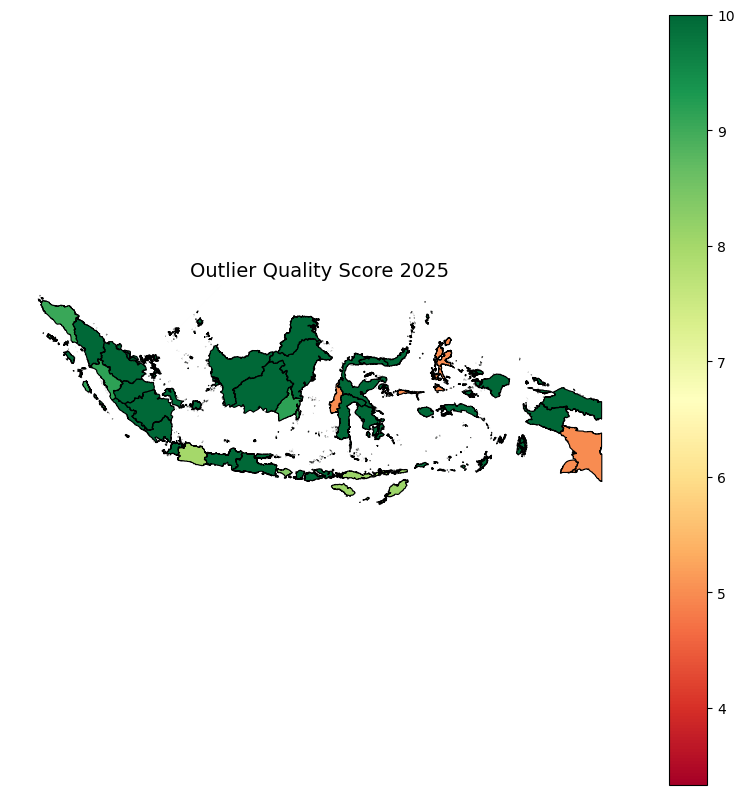

In [385]:
map_2025 = prov_weighted[prov_weighted["Tahun"] == 2025].copy()

gdf_merged = gdf.merge(
    map_2025,
    on="Provinsi",
    how="left"
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_merged.plot(
    column="Outlier_Score_0_10",
    cmap="RdYlGn",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Outlier Quality Score 2025", fontsize=14)
ax.axis("off")

plt.show()

In [387]:
prov_weighted.sort_values("Outlier_Score_0_10", ascending=True)

,Provinsi,Tahun,Anomaly_Rate_FullPanel,Outlier_Quality_Score,Total_Kab,Weighted_Anomaly,Weighted_Anomaly_Normalized,Outlier_Score_0_10
182,Sulawesi Utara,2022,0.666667,0.333333,15.0,2.581989,1.000000,3.333333
30,DKI Jakarta,2025,0.666667,0.333333,6.0,1.632993,0.632456,3.333333
147,Papua Selatan,2025,0.500000,0.500000,4.0,1.000000,0.387298,5.000000
161,Sulawesi Barat,2025,0.500000,0.500000,6.0,1.224745,0.474342,5.000000
120,Maluku Utara,2025,0.500000,0.500000,10.0,1.581139,0.612372,5.000000
...,...,...,...,...,...,...,...,...
81,Kalimantan Tengah,2021,0.000000,1.000000,14.0,0.000000,0.000000,10.000000
82,Kalimantan Tengah,2022,0.000000,1.000000,14.0,0.000000,0.000000,10.000000
83,Kalimantan Tengah,2023,0.000000,1.000000,14.0,0.000000,0.000000,10.000000
74,Kalimantan Selatan,2021,0.000000,1.000000,13.0,0.000000,0.000000,10.000000


In [388]:
import pandas as pd

# --- FILTER VALID REPORTS (at least 1 variable reported) ---
df_valid = df[df["jml_timbulan_tahun"].notna()].copy()

# --- COUNT REPORTING KAB/KOTA PER PROVINCE-YEAR ---
report_count = (
    df_valid.groupby(["Provinsi", "Tahun"])["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Kab_Report")
)

# --- TOTAL KAB/KOTA PER PROVINCE (REFERENCE BASELINE) ---
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab")
)

# --- MERGE & CALCULATE REPORT RATE ---
report_rate = report_count.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

report_rate["Report_Rate"] = (
    report_rate["Kab_Report"] /
    report_rate["Total_Kab"]
)

# --- OPTIONAL: CONVERT TO 0–10 SCALE ---
report_rate["Report_Rate_Score_0_10"] = report_rate["Report_Rate"] * 10

# --- SORT TO INSPECT ---
report_rate.sort_values(["Tahun", "Report_Rate"], ascending=[True, False]).head(20)

,Provinsi,Tahun,Kab_Report,Total_Kab,Report_Rate,Report_Rate_Score_0_10
35,Gorontalo,2019,1,6.0,0.166667,1.666667
47,Jawa Barat,2019,3,27.0,0.111111,1.111111
72,Kalimantan Selatan,2019,1,13.0,0.076923,0.769231
79,Kalimantan Tengah,2019,1,14.0,0.071429,0.714286
179,Sulawesi Utara,2019,1,15.0,0.066667,0.666667
174,Sulawesi Tenggara,2019,1,17.0,0.058824,0.588235
0,Aceh,2019,1,23.0,0.043478,0.434783
198,Sumatera Utara,2019,1,33.0,0.030303,0.303030
96,Kepulauan Bangka Belitung,2020,5,7.0,0.714286,7.142857
73,Kalimantan Selatan,2020,9,13.0,0.692308,6.923077


In [389]:
# --- MERGE REPORT RATE + OUTLIER SCORE ---
quality_df = report_rate.merge(
    prov_weighted[["Provinsi", "Tahun", "Outlier_Quality_Score"]],
    on=["Provinsi", "Tahun"],
    how="left"
)

# --- DEFINE WEIGHTS ---
w_report = 0.6
w_outlier = 0.4

# --- CALCULATE FINAL SCORE (0–1 scale) ---
quality_df["Final_Quality_Score"] = (
    w_report * quality_df["Report_Rate"] +
    w_outlier * quality_df["Outlier_Quality_Score"]
)

# --- CONVERT TO 0–10 SCALE ---
quality_df["Final_Quality_Score_0_10"] = (
    quality_df["Final_Quality_Score"] * 10
)

# --- CHECK RESULT ---
quality_df.head()

,Provinsi,Tahun,Kab_Report,Total_Kab,Report_Rate,Report_Rate_Score_0_10,Outlier_Quality_Score,Final_Quality_Score,Final_Quality_Score_0_10
0,Aceh,2019,1,23.0,0.043478,0.434783,1.0,0.426087,4.260870
1,Aceh,2020,6,23.0,0.260870,2.608696,1.0,0.556522,5.565217
2,Aceh,2021,2,23.0,0.086957,0.869565,1.0,0.452174,4.521739
3,Aceh,2022,8,23.0,0.347826,3.478261,1.0,0.608696,6.086957
4,Aceh,2023,13,23.0,0.565217,5.652174,1.0,0.739130,7.391304


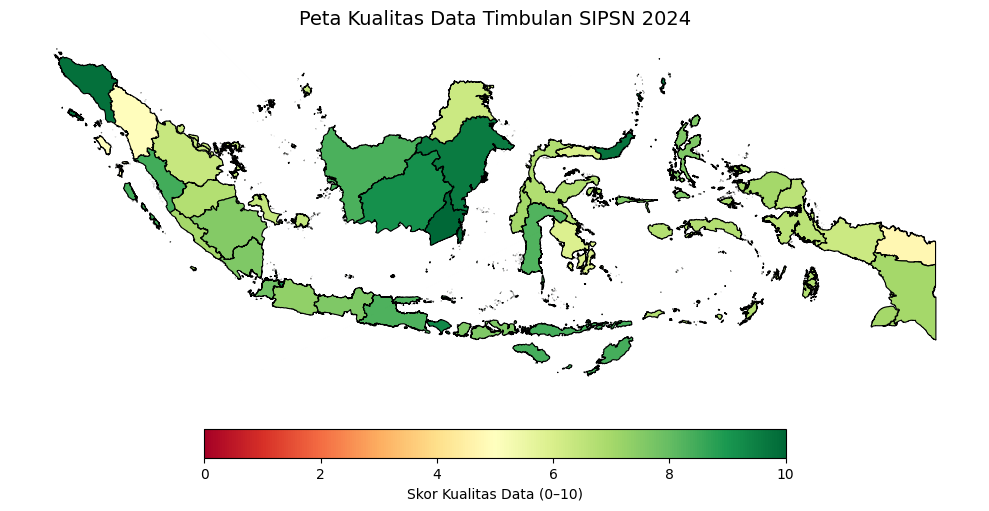

In [390]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 1. SET TAHUN
# ==========================================
year = 2024

# ==========================================
# 2. FILTER DATA KUALITAS SESUAI TAHUN
# ==========================================
quality_year = quality_df[
    quality_df["Tahun"] == year
].copy()

# ==========================================
# 3. SAMAKAN NAMA PROVINSI (JIKA PERLU)
# ==========================================
quality_year["Provinsi"] = (
    quality_year["Provinsi"]
    .replace({
        "D.I. Yogyakarta": "DI Yogyakarta",
        "Bangka Belitung": "Kepulauan Bangka Belitung"
    })
)

# ==========================================
# 4. MERGE DENGAN SHAPEFILE
# ==========================================
gdf_merged = gdf.merge(
    quality_year,
    left_on="name_1",
    right_on="Provinsi",
    how="left"
)

# ==========================================
# 5. PLOT PETA
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf_merged.plot(
    column="Final_Quality_Score_0_10",
    cmap="RdYlGn",
    linewidth=0.8,
    edgecolor="black",
    vmin=0,
    vmax=10,
    ax=ax
)

# ==========================================
# 6. COLORBAR HORIZONTAL
# ==========================================
norm = mpl.colors.Normalize(vmin=0, vmax=10)
sm = mpl.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.04,
    pad=0.05
)

cbar.set_label("Skor Kualitas Data (0–10)")

# ==========================================
# 7. FINAL TOUCH
# ==========================================
ax.set_title(f"Peta Kualitas Data Timbulan SIPSN {year}", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

In [391]:
import pandas as pd

# ===============================
# SET TAHUN
# ===============================
year = 2024

# ===============================
# FILTER DATA TAHUN TERPILIH
# ===============================
df_year = quality_df[
    quality_df["Tahun"] == year
].copy()

# ===============================
# SORTING
# ===============================
df_sorted = df_year.sort_values(
    "Final_Quality_Score_0_10",
    ascending=False
)

# ===============================
# TOP 5
# ===============================
top_5 = df_sorted[["Provinsi", "Final_Quality_Score_0_10"]].head(5)

# ===============================
# BOTTOM 5
# ===============================
bottom_5 = df_sorted.sort_values(
    "Final_Quality_Score_0_10",
    ascending=True
)[["Provinsi", "Final_Quality_Score_0_10"]].head(5)

print("Top 5 Provinsi - Kualitas Data Timbulan")
print(top_5.round(2))

print("\nBottom 5 Provinsi - Kualitas Data Timbulan")
print(bottom_5.round(2))

Top 5 Provinsi - Kualitas Data Timbulan
                       Provinsi  Final_Quality_Score_0_10
33   Daerah Istimewa Yogyakarta                     10.00
77           Kalimantan Selatan                     10.00
5                          Aceh                      9.83
184              Sulawesi Utara                      9.73
90             Kalimantan Timur                      9.60

Bottom 5 Provinsi - Kualitas Data Timbulan
              Provinsi  Final_Quality_Score_0_10
143   Papua Pegunungan                      4.75
203     Sumatera Utara                      4.95
177  Sulawesi Tenggara                      5.90
39           Gorontalo                      6.00
149       Papua Tengah                      6.25


posx and posy should be finite values
posx and posy should be finite values


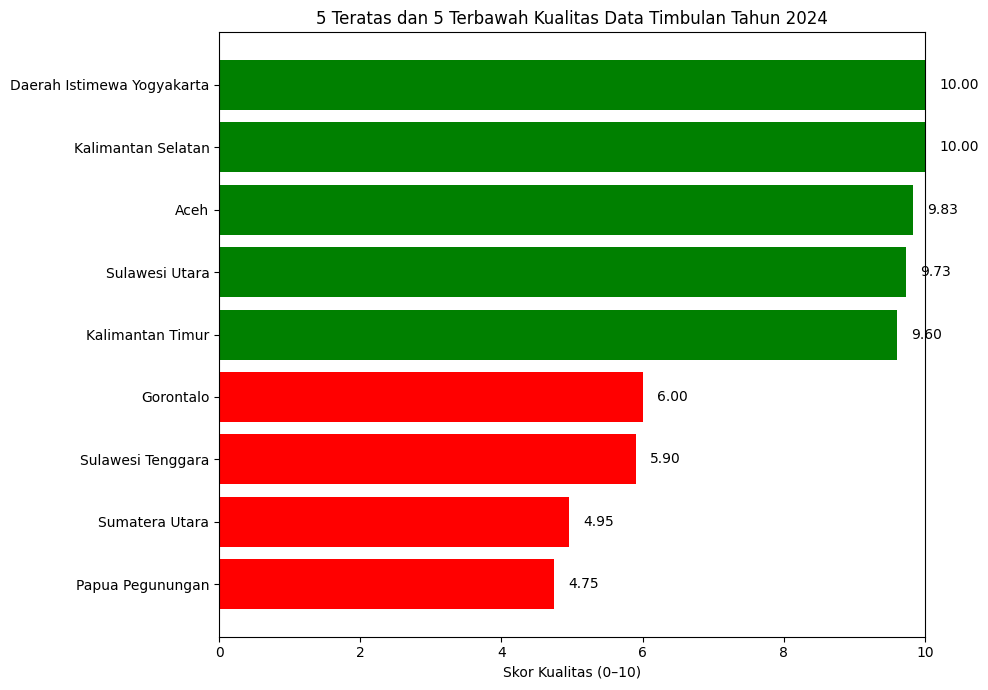

In [392]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# SET TAHUN
# ===============================
year = 2024

# ===============================
# FILTER DATA
# ===============================
df_year = quality_df[
    quality_df["Tahun"] == year
].copy()

# ===============================
# SORT
# ===============================
df_sorted = df_year.sort_values(
    "Final_Quality_Score_0_10",
    ascending=False
)

top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5)

# Combine
plot_df = pd.concat([top_5, bottom_5])

# Add color
plot_df["Color"] = ["green"]*5 + ["red"]*5

# Sort again so highest on top
plot_df = plot_df.sort_values(
    "Final_Quality_Score_0_10",
    ascending=False
)

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(10,7))

bars = plt.barh(
    plot_df["Provinsi"],
    plot_df["Final_Quality_Score_0_10"],
    color=plot_df["Color"]
)

plt.xlim(0,10)
plt.xlabel("Skor Kualitas (0–10)")
plt.title(f"5 Teratas dan 5 Terbawah Kualitas Data Timbulan Tahun {year}")

# Add score labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Sumber sampah

In [255]:
from pathlib import Path
from met_pipeline.io import load_excel, load_csv, normalize_kab_kota
from met_pipeline.quality import compute_entity_completeness

PROJECT_ROOT = Path.cwd().parent

df_sumber = load_excel(
    PROJECT_ROOT / "data" / "raw" / "master_sumber_sipsn_new.xlsx",
    header=0,
)

ref_df = load_csv(
    PROJECT_ROOT / "data" / "reference" / "master_kab_reference_final.csv"
)


In [257]:
df_sumber = df_sumber.rename(columns={
    "tahun": "Tahun",
    "provinsi": "Provinsi",
    "kabkota": "Kabupaten/Kota"
})

In [258]:
sumber_vars = [
    "rumah_tangga",
    "perkantoran",
    "perniagaan",
    "pasar",
    "fasilitas_publik",
    "lainnya",
    "kawasan"
]

In [260]:
ref_df.columns

Index(['provinsi', 'kab_kota'], dtype='object')

In [261]:
ref_df = ref_df.rename(columns={
    "provinsi": "Provinsi",
    "kab_kota": "Kabupaten/Kota"
})

In [262]:
# --- REPORTING FLAG (at least 1 sumber filled) ---
df_sumber["has_report"] = df_sumber[sumber_vars].notna().any(axis=1)

# --- Count reporting kab/kota per province-year ---
report_count_sumber = (
    df_sumber[df_sumber["has_report"]]
    .groupby(["Provinsi", "Tahun"])["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Kab_Report")
)

# --- Total kab/kota baseline ---
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab")
)

# --- Merge and compute report rate ---
report_rate_sumber = report_count_sumber.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

report_rate_sumber["Report_Rate"] = (
    report_rate_sumber["Kab_Report"] /
    report_rate_sumber["Total_Kab"]
)

In [263]:
report_rate_sumber.head()

,Provinsi,Tahun,Kab_Report,Total_Kab,Report_Rate
0,Aceh,2019,1,23.0,0.043478
1,Aceh,2020,5,23.0,0.217391
2,Aceh,2021,2,23.0,0.086957
3,Aceh,2022,6,23.0,0.260870
4,Aceh,2023,13,23.0,0.565217


In [276]:
# --- define sumber variables ---
sumber_vars = [
    "rumah_tangga",
    "perkantoran",
    "perniagaan",
    "pasar",
    "fasilitas_publik",
    "lainnya",
    "kawasan"
]

# --- count filled variables per kab ---
df_sumber["filled_vars"] = df_sumber[sumber_vars].notna().sum(axis=1)

# --- total filled per province-year ---
filled_sum = (
    df_sumber.groupby(["Provinsi", "Tahun"])["filled_vars"]
    .sum()
    .reset_index(name="Total_Filled")
)

# --- total kab baseline ---
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab")
)

# --- merge baseline ---
strict_completeness = filled_sum.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

# --- compute strict completeness ---
strict_completeness["Completeness"] = (
    strict_completeness["Total_Filled"] /
    (strict_completeness["Total_Kab"] * len(sumber_vars))
)

strict_completeness.head()

,Provinsi,Tahun,Total_Filled,Total_Kab,Completeness
0,Aceh,2019,6,23.0,0.037267
1,Aceh,2020,34,23.0,0.211180
2,Aceh,2021,13,23.0,0.080745
3,Aceh,2022,41,23.0,0.254658
4,Aceh,2023,84,23.0,0.521739


In [278]:
sumber_vars = [
    "rumah_tangga",
    "perkantoran",
    "perniagaan",
    "pasar",
    "fasilitas_publik",
    "lainnya",
    "kawasan"
]

In [279]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# -----------------------------
# 1. DEFINE SUMBER VARIABLES
# -----------------------------
sumber_vars = [
    "rumah_tangga",
    "perkantoran",
    "perniagaan",
    "pasar",
    "fasilitas_publik",
    "lainnya",
    "kawasan"
]

# -----------------------------
# 2. KEEP ONLY REPORTING KAB/KOTA
# (at least one sumber variable filled)
# -----------------------------
df_sumber_valid = df_sumber[
    df_sumber[sumber_vars].notna().any(axis=1)
].copy()

# -----------------------------
# 3. COMPUTE TOTAL SUMBER
# -----------------------------
df_sumber_valid["Total_Sumber"] = (
    df_sumber_valid[sumber_vars].sum(axis=1)
)

# -----------------------------
# 4. LOG TRANSFORMATION
# -----------------------------
for col in sumber_vars:
    df_sumber_valid[f"log_{col}"] = np.log1p(df_sumber_valid[col])

df_sumber_valid["log_Total"] = np.log1p(
    df_sumber_valid["Total_Sumber"]
)

# -----------------------------
# 5. COMPUTE GROWTH (TOTAL ONLY)
# -----------------------------
df_sumber_valid = df_sumber_valid.sort_values(
    ["Kabupaten/Kota", "Tahun"]
)

df_sumber_valid["prev_total"] = (
    df_sumber_valid.groupby("Kabupaten/Kota")["Total_Sumber"]
    .shift(1)
)

df_sumber_valid["Growth_Total"] = (
    (df_sumber_valid["Total_Sumber"] -
     df_sumber_valid["prev_total"])
    / df_sumber_valid["prev_total"]
)

df_sumber_valid["Growth_Total"] = (
    df_sumber_valid["Growth_Total"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# -----------------------------
# 6. BUILD FEATURE MATRIX (9 VARIABLES)
# -----------------------------
log_vars = [f"log_{col}" for col in sumber_vars]

feature_cols = log_vars + ["log_Total", "Growth_Total"]

features = df_sumber_valid[feature_cols]

# -----------------------------
# 7. STANDARDIZE
# -----------------------------
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# -----------------------------
# 8. ISOLATION FOREST
# -----------------------------
iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

df_sumber_valid["anomaly_flag"] = iso.fit_predict(features_scaled)
df_sumber_valid["is_anomaly"] = (
    df_sumber_valid["anomaly_flag"] == -1
).astype(int)

# -----------------------------
# 9. AGGREGATE TO PROVINCE-YEAR
# -----------------------------
outlier_sumber = (
    df_sumber_valid
    .groupby(["Provinsi", "Tahun"])["is_anomaly"]
    .mean()
    .reset_index(name="Anomaly_Rate")
)

outlier_sumber["Outlier_Quality_Score"] = (
    1 - outlier_sumber["Anomaly_Rate"]
)

outlier_sumber.sort_values(
    ["Tahun", "Anomaly_Rate"],
    ascending=[True, False]
).head(20)

,Provinsi,Tahun,Anomaly_Rate,Outlier_Quality_Score
0,Aceh,2019,0.000000,1.000000
29,Gorontalo,2019,0.000000,1.000000
65,Kalimantan Selatan,2019,0.000000,1.000000
72,Kalimantan Tengah,2019,0.000000,1.000000
159,Sulawesi Utara,2019,0.000000,1.000000
178,Sumatera Utara,2019,0.000000,1.000000
12,Banten,2020,0.500000,0.500000
139,Sulawesi Barat,2020,0.500000,0.500000
24,Daerah Istimewa Yogyakarta,2020,0.333333,0.666667
47,Jawa Tengah,2020,0.272727,0.727273


In [280]:
df_sumber[df_sumber["Provinsi"]=="Sulawesi Barat"]

,Tahun,periode,Provinsi,Kabupaten/Kota,rumah_tangga,perkantoran,perniagaan,pasar,fasilitas_publik,lainnya,kawasan,has_report,filled_vars
165,2020,1,Sulawesi Barat,Kab. Pasangkayu,2839.90,178.20,181.00,1109.00,150.00,154.00,146.7,True,7
166,2020,1,Sulawesi Barat,Kab. Polewali Mandar,110.23,5.46,8.93,12.86,19.88,7.14,14.5,True,7
428,2022,1,Sulawesi Barat,Kab. Mamuju,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0
629,2023,1,Sulawesi Barat,Kab. Pasangkayu,9.05,0.50,NaN,1.00,0.25,NaN,NaN,True,4
630,2023,1,Sulawesi Barat,Kab. Mamuju,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0
631,2023,1,Sulawesi Barat,Kab. Majene,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0
947,2024,1,Sulawesi Barat,Kab. Pasangkayu,6.00,0.08,NaN,0.45,0.08,0.08,0.0,True,6
948,2024,1,Sulawesi Barat,Kab. Mamuju,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0
949,2024,1,Sulawesi Barat,Kab. Majene,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0
1210,2025,1,Sulawesi Barat,Kab. Pasangkayu,45.00,1.20,1.80,7.20,2.40,1.20,1.2,True,7


In [268]:
outlier_sumber["Anomaly_Rate"].describe()

count    185.000000
mean       0.038820
std        0.101907
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.500000
Name: Anomaly_Rate, dtype: float64

In [269]:
# -----------------------------
# 1. MERGE ALL THREE DIMENSIONS
# -----------------------------
quality_sumber = (
    report_rate_sumber
    .merge(
        strict_completeness[["Provinsi", "Tahun", "Completeness"]],
        on=["Provinsi", "Tahun"],
        how="left"
    )
    .merge(
        outlier_sumber[["Provinsi", "Tahun", "Outlier_Quality_Score"]],
        on=["Provinsi", "Tahun"],
        how="left"
    )
)

# -----------------------------
# 2. HANDLE POSSIBLE NaN (if province-year missing anomaly)
# -----------------------------
quality_sumber["Outlier_Quality_Score"] = (
    quality_sumber["Outlier_Quality_Score"].fillna(1)
)

quality_sumber["Completeness"] = (
    quality_sumber["Completeness"].fillna(0)
)

quality_sumber["Report_Rate"] = (
    quality_sumber["Report_Rate"].fillna(0)
)

# -----------------------------
# 3. DEFINE WEIGHTS
# -----------------------------
w_report = 0.3
w_complete = 0.4
w_outlier = 0.30

# -----------------------------
# 4. CALCULATE FINAL SCORE (0–1 scale)
# -----------------------------
quality_sumber["Final_Sumber_Score"] = (
    w_report * quality_sumber["Report_Rate"] +
    w_complete * quality_sumber["Completeness"] +
    w_outlier * quality_sumber["Outlier_Quality_Score"]
)

# -----------------------------
# 5. CONVERT TO 0–10 SCALE
# -----------------------------
quality_sumber["Final_Sumber_Score_0_10"] = (
    quality_sumber["Final_Sumber_Score"] * 10
)

# -----------------------------
# 6. SORT TO INSPECT
# -----------------------------
quality_sumber.sort_values(
    ["Tahun", "Final_Sumber_Score"],
    ascending=[True, False]
).head(20)

,Provinsi,Tahun,Kab_Report,Total_Kab,Report_Rate,Completeness,Outlier_Quality_Score,Final_Sumber_Score,Final_Sumber_Score_0_10
29,Gorontalo,2019,1,6.0,0.166667,0.166667,1.000000,0.416667,4.166667
65,Kalimantan Selatan,2019,1,13.0,0.076923,0.076923,1.000000,0.353846,3.538462
72,Kalimantan Tengah,2019,1,14.0,0.071429,0.071429,1.000000,0.350000,3.500000
159,Sulawesi Utara,2019,1,15.0,0.066667,0.066667,1.000000,0.346667,3.466667
0,Aceh,2019,1,23.0,0.043478,0.037267,1.000000,0.327950,3.279503
178,Sumatera Utara,2019,1,33.0,0.030303,0.030303,1.000000,0.321212,3.212121
93,Kepulauan Riau,2020,4,7.0,0.571429,0.571429,1.000000,0.700000,7.000000
66,Kalimantan Selatan,2020,7,13.0,0.538462,0.461538,1.000000,0.646154,6.461538
87,Kepulauan Bangka Belitung,2020,3,7.0,0.428571,0.428571,1.000000,0.600000,6.000000
24,Daerah Istimewa Yogyakarta,2020,3,5.0,0.600000,0.514286,0.666667,0.585714,5.857143


In [270]:
year = 2024

quality_2025 = quality_sumber[
    quality_sumber["Tahun"] == year
].copy()

In [271]:
quality_2025["Provinsi"] = (
    quality_2025["Provinsi"]
    .replace({
        "D.I. Yogyakarta": "DI Yogyakarta",
        "Bangka Belitung": "Kepulauan Bangka Belitung"
    })
)

In [272]:
gdf_merged = gdf.merge(
    quality_2025,
    left_on="name_1",
    right_on="Provinsi",
    how="left"
)

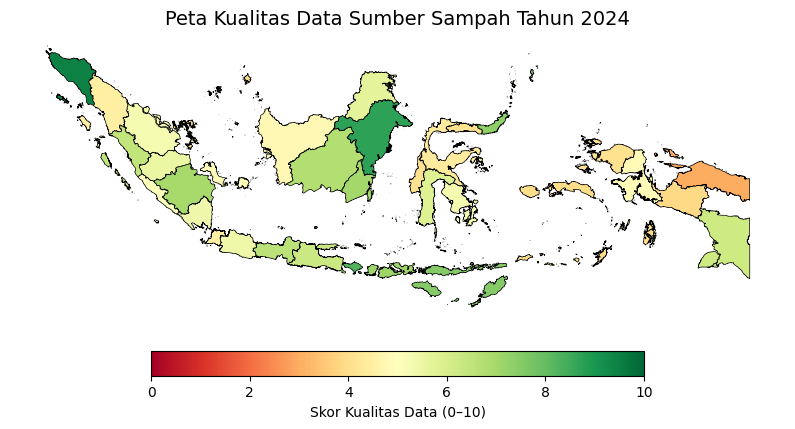

In [275]:
import matplotlib.pyplot as plt
import matplotlib as mpl

year = 2024

quality_2025 = quality_sumber[
    quality_sumber["Tahun"] == year
].copy()

# Merge
gdf_merged = gdf.merge(
    quality_2025,
    left_on="name_1",
    right_on="Provinsi",
    how="left"
)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot tanpa legend otomatis
gdf_merged.plot(
    column="Final_Sumber_Score_0_10",
    cmap="RdYlGn",
    linewidth=0.5,
    edgecolor="black",
    vmin=0,
    vmax=10,
    ax=ax
)

# Buat colorbar horizontal
norm = mpl.colors.Normalize(vmin=0, vmax=10)
sm = mpl.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.04,
    pad=0.05
)

cbar.set_label("Skor Kualitas Data (0–10)")

ax.set_title(f"Peta Kualitas Data Sumber Sampah Tahun {year}", fontsize=14)
ax.axis("off")

plt.show()

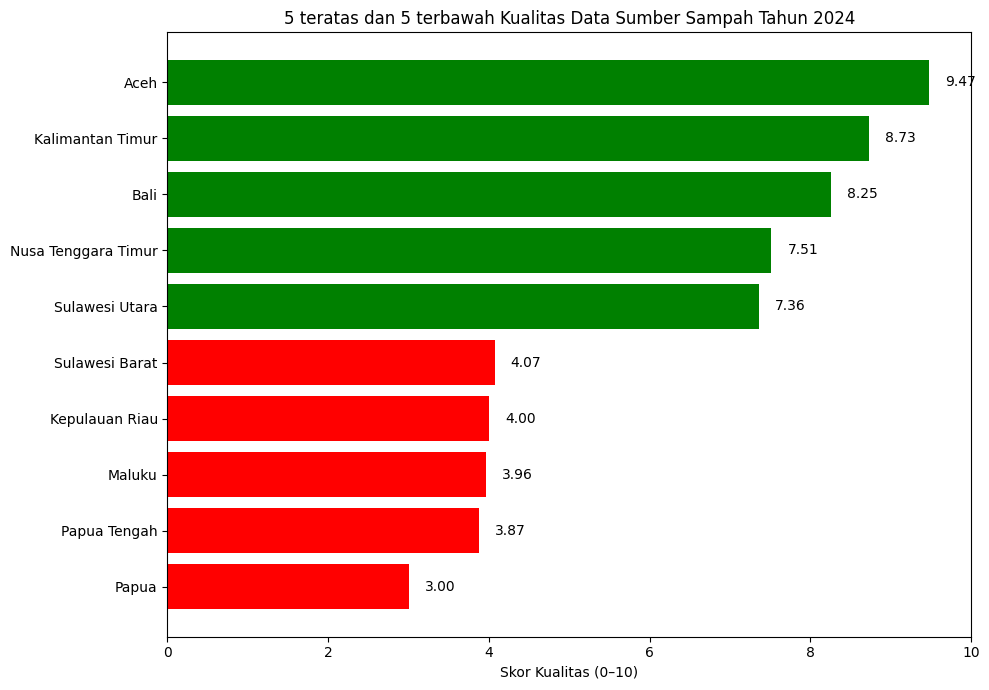

In [285]:
import matplotlib.pyplot as plt

# ===============================
# PILIH TAHUN
# ===============================
year = 2024

df_year = gdf_merged[
    gdf_merged["Tahun"] == year
].copy()

# Urutkan
df_sorted = df_year.sort_values(
    "Final_Sumber_Score_0_10",
    ascending=False
)

# Ambil Top 5 dan Bottom 5
top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5)

# Gabungkan
plot_df = pd.concat([top_5, bottom_5])

# Tambahkan warna
plot_df["Warna"] = ["Hijau"]*5 + ["Merah"]*5

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(10, 7))

colors = plot_df["Warna"].map({
    "Hijau": "green",
    "Merah": "red"
})

bars = plt.barh(
    plot_df["name_1"],
    plot_df["Final_Sumber_Score_0_10"],
    color=colors
)

plt.xlim(0, 10)
plt.xlabel("Skor Kualitas (0–10)")
plt.title(f"5 teratas dan 5 terbawah Kualitas Data Sumber Sampah Tahun {year}")

# Tambahkan label skor di ujung bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Komposisi


In [304]:
from pathlib import Path
from met_pipeline.io import load_excel, load_csv, normalize_kab_kota
from met_pipeline.quality import compute_entity_completeness

PROJECT_ROOT = Path.cwd().parent

df_komposisi = load_excel(
    PROJECT_ROOT / "data" / "raw" / "master_komposisi_sipsn_new.xlsx",
    header=0,
)

ref_df = load_csv(
    PROJECT_ROOT / "data" / "reference" / "master_kab_reference_final.csv"
)


In [305]:
df_komposisi.columns

Index(['tahun', 'periode', 'provinsi', 'kabkota', 'sisa makanan',
       'kayu ranting', 'kertas/karton', 'plastik', 'logam', 'kain',
       'karet/kulit', 'kaca', 'lainnya'],
      dtype='object')

In [307]:
df_komposisi = df_komposisi.rename(columns={
    "tahun": "Tahun",
    "provinsi": "Provinsi",
    "kabkota": "Kabupaten/Kota"
})

In [308]:
komposisi_vars = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

In [309]:
df_komposisi["Total_Persen"] = df_komposisi[komposisi_vars].sum(axis=1)

df_komposisi["Total_Persen"].describe()

count    1224.000000
mean       78.402655
std        41.973858
min         0.000000
25%        99.900000
50%       100.000000
75%       100.000000
max       403.620000
Name: Total_Persen, dtype: float64

In [311]:
df_komposisi["Provinsi"].unique()

array(['Aceh', 'Sumatera Utara', 'Jawa Barat', 'Kalimantan Tengah',
       'Kalimantan Selatan', 'Sulawesi Utara', 'Sulawesi Tenggara',
       'Gorontalo', 'Sumatera Barat', 'Riau', 'Jambi', 'Sumatera Selatan',
       'Bengkulu', 'Lampung', 'Kepulauan Bangka Belitung',
       'Kepulauan Riau', 'Jawa Tengah', 'Daerah Istimewa Yogyakarta',
       'Jawa Timur', 'Banten', 'Bali', 'Kalimantan Barat',
       'Kalimantan Timur', 'Kalimantan Utara', 'Sulawesi Tengah',
       'Sulawesi Selatan', 'Sulawesi Barat', 'Maluku', 'Maluku Utara',
       'Papua Barat', 'DKI Jakarta', 'Nusa Tenggara Barat', 'Papua',
       'Papua Selatan', 'Papua Barat Daya', 'Nusa Tenggara Timur',
       'Papua Tengah', 'Papua Pegunungan'], dtype=object)

In [312]:
# define komposisi variables
komposisi_vars = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# reporting flag
df_komposisi["has_report"] = (
    df_komposisi[komposisi_vars].notna().any(axis=1)
)

# count reporting kab/kota
report_count_komposisi = (
    df_komposisi[df_komposisi["has_report"]]
    .groupby(["Provinsi", "Tahun"])["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Kab_Report")
)

# total kab baseline
ref_df = ref_df.rename(columns={
    "provinsi": "Provinsi",
    "kab_kota": "Kabupaten/Kota"
})

total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab")
)

# compute report rate
report_rate_komposisi = report_count_komposisi.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

report_rate_komposisi["Report_Rate"] = (
    report_rate_komposisi["Kab_Report"] /
    report_rate_komposisi["Total_Kab"]
)

report_rate_komposisi.head()

,Provinsi,Tahun,Kab_Report,Total_Kab,Report_Rate
0,Aceh,2019,1,23.0,0.043478
1,Aceh,2020,4,23.0,0.173913
2,Aceh,2021,2,23.0,0.086957
3,Aceh,2022,7,23.0,0.304348
4,Aceh,2023,12,23.0,0.521739


In [313]:
import numpy as np

# -----------------------------
# 1. RENAME COLUMNS (if not yet)
# -----------------------------
df_komposisi = df_komposisi.rename(columns={
    "tahun": "Tahun",
    "provinsi": "Provinsi",
    "kabkota": "Kabupaten/Kota"
})

# -----------------------------
# 2. DEFINE KOMPOSISI VARIABLES
# -----------------------------
komposisi_vars = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# -----------------------------
# 3. COMPUTE TOTAL PERCENTAGE
# -----------------------------
df_komposisi["Total_Persen"] = (
    df_komposisi[komposisi_vars]
    .sum(axis=1, skipna=True)
)

# -----------------------------
# 4. COMPUTE DEVIATION
# -----------------------------
df_komposisi["Deviation"] = (
    (df_komposisi["Total_Persen"] - 100).abs()
)

# -----------------------------
# 5. COMPUTE COMPLETENESS (0–1 SCALE)
# Formula:
# Completeness = max(0, 1 - Deviation/100)
# -----------------------------
df_komposisi["Completeness"] = (
    1 - df_komposisi["Deviation"] / 100
)

df_komposisi["Completeness"] = (
    df_komposisi["Completeness"]
    .clip(lower=0)
)

# -----------------------------
# 6. CONVERT TO 0–10 SCALE
# -----------------------------
df_komposisi["Completeness_0_10"] = (
    df_komposisi["Completeness"] * 10
)

# -----------------------------
# 7. AGGREGATE TO PROVINCE-YEAR
# (average across kab/kota)
# -----------------------------
completeness_komposisi = (
    df_komposisi
    .groupby(["Provinsi", "Tahun"])["Completeness"]
    .mean()
    .reset_index()
)

completeness_komposisi["Completeness_0_10"] = (
    completeness_komposisi["Completeness"] * 10
)

completeness_komposisi.sort_values(
    ["Tahun", "Completeness"],
    ascending=[True, False]
).head(20)

,Provinsi,Tahun,Completeness,Completeness_0_10
35,Gorontalo,2019,1.000000,10.000000
72,Kalimantan Selatan,2019,1.000000,10.000000
79,Kalimantan Tengah,2019,1.000000,10.000000
179,Sulawesi Utara,2019,1.000000,10.000000
198,Sumatera Utara,2019,0.913000,9.130000
0,Aceh,2019,0.890000,8.900000
47,Jawa Barat,2019,0.333333,3.333333
174,Sulawesi Tenggara,2019,0.000000,0.000000
36,Gorontalo,2020,1.000000,10.000000
86,Kalimantan Timur,2020,1.000000,10.000000


In [314]:
completeness_komposisi["Provinsi"].unique()

array(['Aceh', 'Bali', 'Banten', 'Bengkulu', 'DKI Jakarta',
       'Daerah Istimewa Yogyakarta', 'Gorontalo', 'Jambi', 'Jawa Barat',
       'Jawa Tengah', 'Jawa Timur', 'Kalimantan Barat',
       'Kalimantan Selatan', 'Kalimantan Tengah', 'Kalimantan Timur',
       'Kalimantan Utara', 'Kepulauan Bangka Belitung', 'Kepulauan Riau',
       'Lampung', 'Maluku', 'Maluku Utara', 'Nusa Tenggara Barat',
       'Nusa Tenggara Timur', 'Papua', 'Papua Barat', 'Papua Barat Daya',
       'Papua Pegunungan', 'Papua Selatan', 'Papua Tengah', 'Riau',
       'Sulawesi Barat', 'Sulawesi Selatan', 'Sulawesi Tengah',
       'Sulawesi Tenggara', 'Sulawesi Utara', 'Sumatera Barat',
       'Sumatera Selatan', 'Sumatera Utara'], dtype=object)

In [315]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# -----------------------------
# 1. DEFINE KOMPOSISI VARIABLES
# -----------------------------
komposisi_vars = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# -----------------------------
# 2. KEEP ONLY REPORTING KAB/KOTA
# -----------------------------
df_kom_valid = df_komposisi[
    df_komposisi[komposisi_vars].notna().any(axis=1)
].copy()

# Fill NaN with 0 (treat blank as 0%)
df_kom_valid[komposisi_vars] = (
    df_kom_valid[komposisi_vars].fillna(0)
)

# -----------------------------
# 3. RUN ISOLATION FOREST PER YEAR
# -----------------------------
df_kom_valid["is_anomaly"] = 0

for year in df_kom_valid["Tahun"].unique():
    
    df_year = df_kom_valid[df_kom_valid["Tahun"] == year]
    
    # Skip if too few observations
    if len(df_year) < 10:
        continue
    
    features = df_year[komposisi_vars]
    
    # Standardize
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    # Isolation Forest
    iso = IsolationForest(
        n_estimators=300,
        contamination=0.05,
        random_state=42
    )
    
    anomaly_flag = iso.fit_predict(features_scaled)
    
    df_kom_valid.loc[df_year.index, "is_anomaly"] = (
        (anomaly_flag == -1).astype(int)
    )

# -----------------------------
# 4. AGGREGATE TO PROVINCE-YEAR
# -----------------------------
outlier_komposisi = (
    df_kom_valid
    .groupby(["Provinsi", "Tahun"])["is_anomaly"]
    .mean()
    .reset_index(name="Anomaly_Rate")
)

outlier_komposisi["Outlier_Quality_Score"] = (
    1 - outlier_komposisi["Anomaly_Rate"]
)

# Inspect highest anomaly provinces
outlier_komposisi.sort_values(
    ["Tahun", "Anomaly_Rate"],
    ascending=[True, False]
).head(20)

,Provinsi,Tahun,Anomaly_Rate,Outlier_Quality_Score
0,Aceh,2019,0.00,1.00
31,Gorontalo,2019,0.00,1.00
43,Jawa Barat,2019,0.00,1.00
68,Kalimantan Selatan,2019,0.00,1.00
75,Kalimantan Tengah,2019,0.00,1.00
164,Sulawesi Utara,2019,0.00,1.00
183,Sumatera Utara,2019,0.00,1.00
1,Aceh,2020,0.50,0.50
144,Sulawesi Barat,2020,0.50,0.50
138,Riau,2020,0.40,0.60


In [316]:
# -----------------------------
# 1. MERGE ALL DIMENSIONS
# -----------------------------
quality_komposisi = (
    report_rate_komposisi
    .merge(
        completeness_komposisi[["Provinsi", "Tahun", "Completeness"]],
        on=["Provinsi", "Tahun"],
        how="left"
    )
    .merge(
        outlier_komposisi[["Provinsi", "Tahun", "Outlier_Quality_Score"]],
        on=["Provinsi", "Tahun"],
        how="left"
    )
)

# -----------------------------
# 2. HANDLE MISSING VALUES
# -----------------------------
quality_komposisi["Completeness"] = (
    quality_komposisi["Completeness"].fillna(0)
)

quality_komposisi["Outlier_Quality_Score"] = (
    quality_komposisi["Outlier_Quality_Score"].fillna(1)
)

quality_komposisi["Report_Rate"] = (
    quality_komposisi["Report_Rate"].fillna(0)
)

# -----------------------------
# 3. DEFINE WEIGHTS
# -----------------------------
w_report = 0.4
w_complete = 0.3
w_outlier = 0.3

# -----------------------------
# 4. CALCULATE FINAL SCORE (0–1)
# -----------------------------
quality_komposisi["Final_Quality"] = (
    w_report * quality_komposisi["Report_Rate"] +
    w_complete * quality_komposisi["Completeness"] +
    w_outlier * quality_komposisi["Outlier_Quality_Score"]
)

# -----------------------------
# 5. CONVERT TO 0–10 SCALE
# -----------------------------
quality_komposisi["Final_Quality_0_10"] = (
    quality_komposisi["Final_Quality"] * 10
)

# -----------------------------
# 6. SORT FOR INSPECTION
# -----------------------------
quality_komposisi.sort_values(
    ["Tahun", "Final_Quality"],
    ascending=[True, False]
).head(20)

,Provinsi,Tahun,Kab_Report,Total_Kab,Report_Rate,Completeness,Outlier_Quality_Score,Final_Quality,Final_Quality_0_10
31,Gorontalo,2019,1,6.0,0.166667,1.000000,1.00,0.666667,6.666667
68,Kalimantan Selatan,2019,1,13.0,0.076923,1.000000,1.00,0.630769,6.307692
75,Kalimantan Tengah,2019,1,14.0,0.071429,1.000000,1.00,0.628571,6.285714
164,Sulawesi Utara,2019,1,15.0,0.066667,1.000000,1.00,0.626667,6.266667
183,Sumatera Utara,2019,1,33.0,0.030303,0.913000,1.00,0.586021,5.860212
0,Aceh,2019,1,23.0,0.043478,0.890000,1.00,0.584391,5.843913
43,Jawa Barat,2019,1,27.0,0.037037,0.333333,1.00,0.414815,4.148148
69,Kalimantan Selatan,2020,9,13.0,0.692308,0.999989,1.00,0.876920,8.769197
98,Kepulauan Riau,2020,4,7.0,0.571429,1.000000,1.00,0.828571,8.285714
82,Kalimantan Timur,2020,5,10.0,0.500000,1.000000,1.00,0.800000,8.000000


In [317]:
gdf["name_1"].unique()

array(['Bali', 'Banten', 'DI Yogyakarta', 'DKI Jakarta', 'Jawa Barat',
       'Jawa Tengah', 'Jawa Timur', 'Kalimantan Barat',
       'Kalimantan Selatan', 'Kalimantan Tengah', 'Kalimantan Timur',
       'Kalimantan Utara', 'Maluku', 'Maluku Utara', 'Papua',
       'Papua Barat', 'Papua Barat Daya', 'Papua Pegunungan',
       'Papua Selatan', 'Papua Tengah', 'Nusa Tenggara Barat',
       'Nusa Tenggara Timur', 'Gorontalo', 'Sulawesi Barat',
       'Sulawesi Selatan', 'Sulawesi Tengah', 'Sulawesi Tenggara',
       'Sulawesi Utara', 'Aceh', 'Bengkulu', 'Jambi',
       'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'Lampung', 'Riau',
       'Sumatera Barat', 'Sumatera Selatan', 'Sumatera Utara'],
      dtype=object)

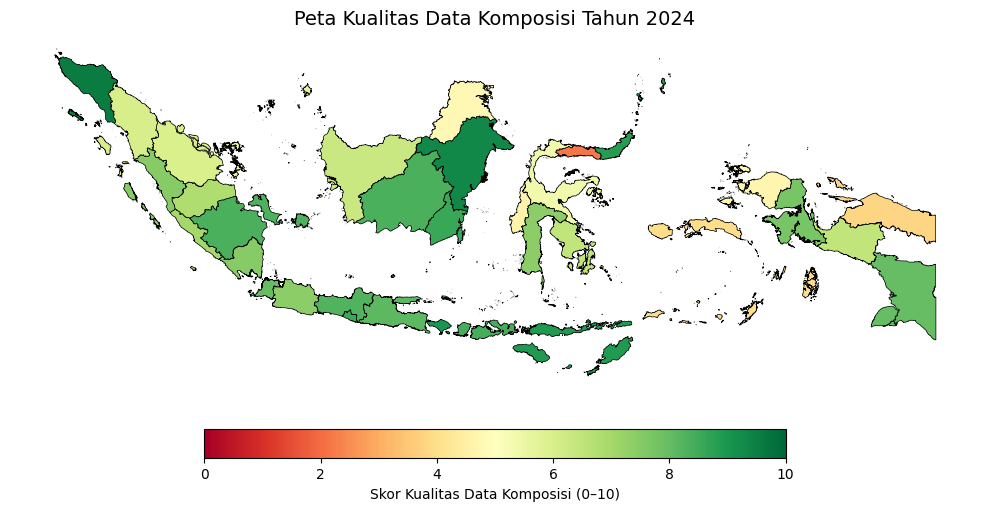

In [318]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ===============================
# SET TAHUN
# ===============================
year = 2024

# ===============================
# FILTER DATA TAHUN TERPILIH
# ===============================
quality_2025 = quality_komposisi[
    quality_komposisi["Tahun"] == year
].copy()

# ===============================
# SAMAKAN NAMA PROVINSI (JIKA PERLU)
# ===============================
quality_2025["Provinsi"] = (
    quality_2025["Provinsi"]
    .replace({
        "Daerah Istimewa Yogyakarta": "DI Yogyakarta",
        "Bangka Belitung": "Kepulauan Bangka Belitung"
    })
)

# ===============================
# MERGE DENGAN SHAPEFILE
# ===============================
gdf_merged_ss = gdf.merge(
    quality_2025,
    left_on="name_1",
    right_on="Provinsi",
    how="left"
)

# ===============================
# PLOT PETA
# ===============================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf_merged_ss.plot(
    column="Final_Quality_0_10",
    cmap="RdYlGn",
    linewidth=0.5,
    edgecolor="black",
    vmin=0,
    vmax=10,
    ax=ax
)

# ===============================
# COLORBAR HORIZONTAL
# ===============================
norm = mpl.colors.Normalize(vmin=0, vmax=10)
sm = mpl.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.04,
    pad=0.05
)

cbar.set_label("Skor Kualitas Data Komposisi (0–10)")

ax.set_title(f"Peta Kualitas Data Komposisi Tahun {year}", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

In [321]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# PILIH TAHUN
# ===============================
year = 2024

df_year = gdf_merged_ss[
    gdf_merged_ss["Tahun"] == year
].copy()

# ===============================
# URUTKAN
# ===============================
df_sorted = df_year.sort_values(
    "Final_Quality_0_10",
    ascending=False
)

# Top 5
top_5 = df_sorted[["name_1", "Final_Quality_0_10"]].head(5)

# Bottom 5
bottom_5 = df_sorted.sort_values(
    "Final_Quality_0_10"
)[["name_1", "Final_Quality_0_10"]].head(5)

print("Top 5 Provinsi - Kualitas Data Komposisi")
print(top_5.round(2))

print("\nBottom 5 Provinsi - Kualitas Data Komposisi")
print(bottom_5.round(2))

Top 5 Provinsi - Kualitas Data Komposisi
                 name_1  Final_Quality_0_10
28                 Aceh                9.61
10     Kalimantan Timur                9.30
0                  Bali                9.00
21  Nusa Tenggara Timur                8.91
27       Sulawesi Utara                8.84

Bottom 5 Provinsi - Kualitas Data Komposisi
              name_1  Final_Quality_0_10
22         Gorontalo                2.17
14             Papua                3.80
12            Maluku                3.96
23    Sulawesi Barat                4.65
16  Papua Barat Daya                4.67


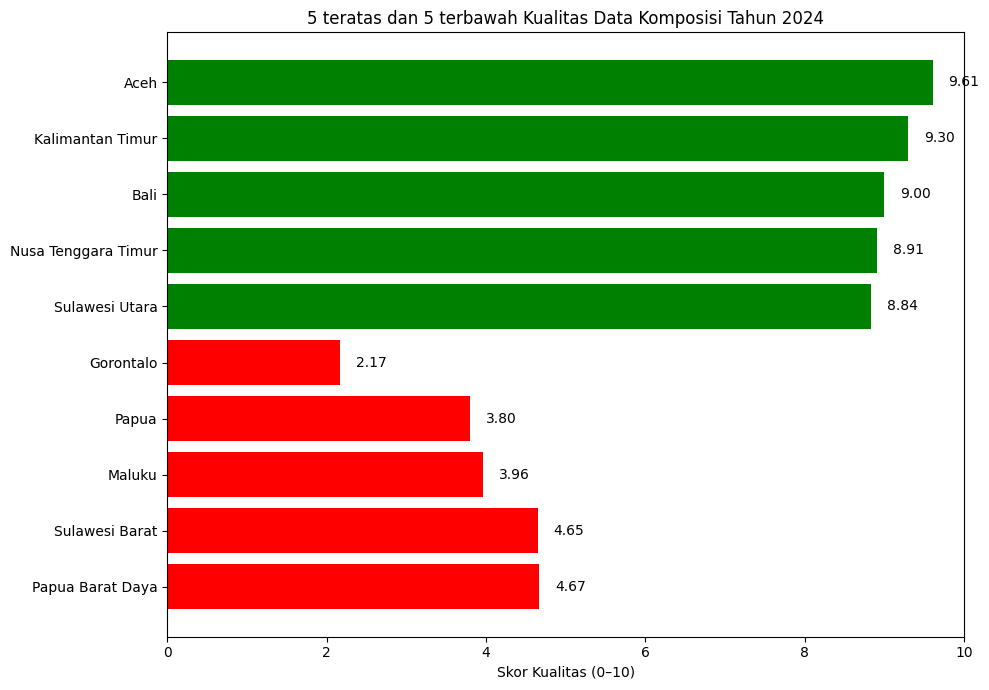

In [323]:
plot_df = pd.concat([top_5, bottom_5])

colors = ["green"]*5 + ["red"]*5

plt.figure(figsize=(10,7))

bars = plt.barh(
    plot_df["name_1"],
    plot_df["Final_Quality_0_10"],
    color=colors
)

plt.xlim(0,10)
plt.xlabel("Skor Kualitas (0–10)")
plt.title(f"5 teratas dan 5 terbawah Kualitas Data Komposisi Tahun {year}")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

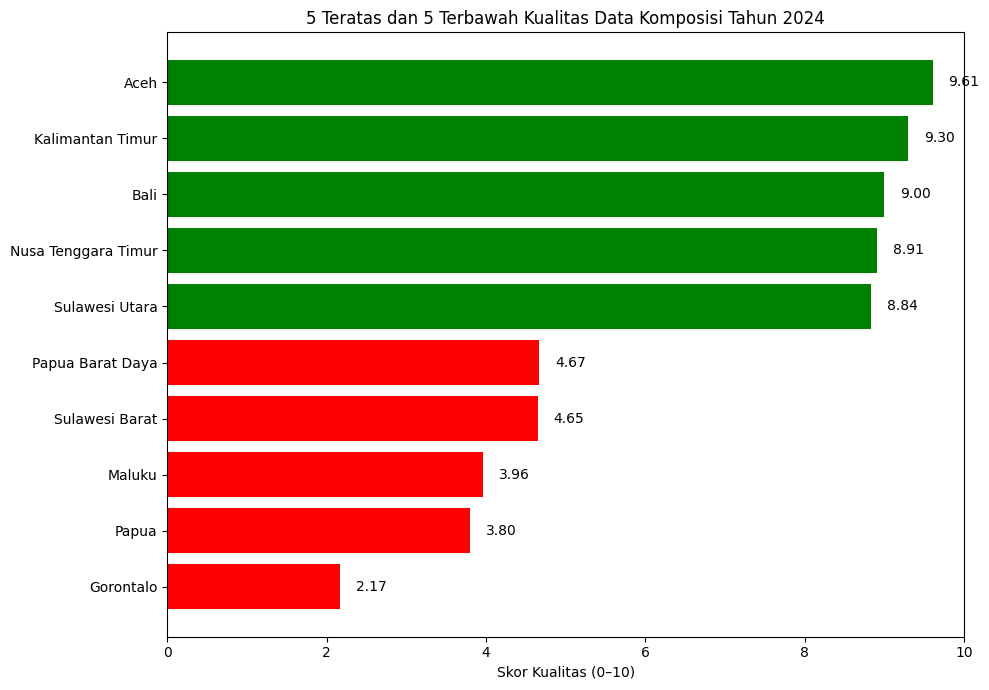

In [324]:
# ===============================
# URUTKAN DATA
# ===============================
df_sorted = df_year.sort_values(
    "Final_Quality_0_10",
    ascending=False
)

# Top 5 (tinggi → lebih rendah)
top_5 = df_sorted.head(5)

# Bottom 5 (rendah → lebih tinggi)
bottom_5 = df_sorted.sort_values(
    "Final_Quality_0_10",
    ascending=True
).head(5)

# Gabungkan dengan urutan yang lebih rapi
plot_df = pd.concat([top_5, bottom_5])

# Tambahkan warna
plot_df["Color"] = ["green"]*5 + ["red"]*5

# ===============================
# SORT ULANG UNTUK VISUAL YANG SIMETRIS
# ===============================
plot_df = plot_df.sort_values(
    "Final_Quality_0_10",
    ascending=False
)

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(10,7))

bars = plt.barh(
    plot_df["name_1"],
    plot_df["Final_Quality_0_10"],
    color=plot_df["Color"]
)

plt.xlim(0,10)
plt.xlabel("Skor Kualitas (0–10)")
plt.title(f"5 Teratas dan 5 Terbawah Kualitas Data Komposisi Tahun {year}")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [184]:
#update 

In [394]:
df_komposisi

,Tahun,periode,Provinsi,Kabupaten/Kota,sisa makanan,kayu ranting,kertas/karton,plastik,logam,kain,karet/kulit,kaca,lainnya,Total_Persen,has_report,Deviation,Completeness,Completeness_0_10
0,2019,1,Aceh,Kota Langsa,17.0,20.00,7.00,7.00,12.00,6.00,8.00,5.00,7.0,89.0,True,11.0,0.890,8.90
1,2019,1,Sumatera Utara,Kab. Langkat,22.9,19.90,18.90,14.60,1.00,3.00,2.00,2.00,7.0,91.3,True,8.7,0.913,9.13
2,2019,1,Jawa Barat,Kab. Bandung,42.0,10.00,10.00,20.00,2.00,1.00,NaN,1.00,14.0,100.0,True,0.0,1.000,10.00
3,2019,1,Jawa Barat,Kab. Bekasi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,100.0,0.000,0.00
4,2019,1,Jawa Barat,Kab. Pangandaran,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,100.0,0.000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219,2025,1,Papua,Kota Jayapura,54.0,9.50,5.80,15.79,2.30,3.07,2.05,1.49,6.0,100.0,True,0.0,1.000,10.00
1220,2025,1,Papua Selatan,Kab. Boven Digoel,5.0,5.00,2.00,70.00,1.00,1.00,1.00,1.00,14.0,100.0,True,0.0,1.000,10.00
1221,2025,1,Papua Selatan,Kab. Asmat,23.0,10.00,15.00,30.00,5.00,5.00,5.00,3.00,4.0,100.0,True,0.0,1.000,10.00
1222,2025,1,Papua Tengah,Kab. Mimika,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,100.0,0.000,0.00


heatmap

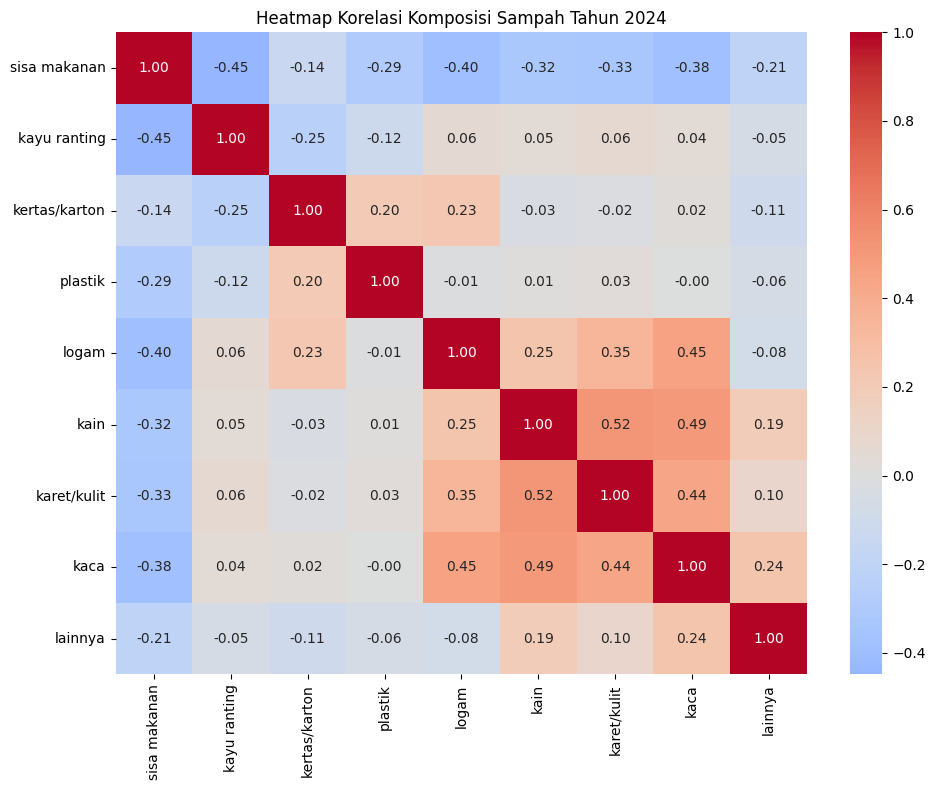

In [459]:
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# PILIH TAHUN
# ===============================
year = 2024

df_year = df_komposisi[
    df_komposisi["Tahun"] == year
].copy()

komposisi_cols = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# ===============================
# HITUNG KORELASI
# ===============================
corr_matrix = df_year[komposisi_cols].corr()

# ===============================
# PLOT HEATMAP KORELASI
# ===============================
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title(f"Heatmap Korelasi Komposisi Sampah Tahun {year}")
plt.tight_layout()
plt.show()

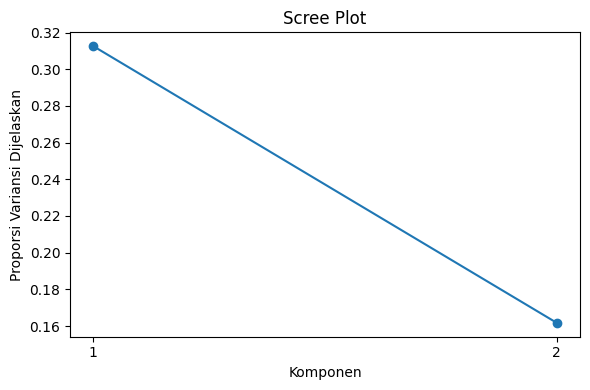

In [408]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.title("Scree Plot")
plt.xlabel("Komponen")
plt.ylabel("Proporsi Variansi Dijelaskan")

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.tight_layout()
plt.show()

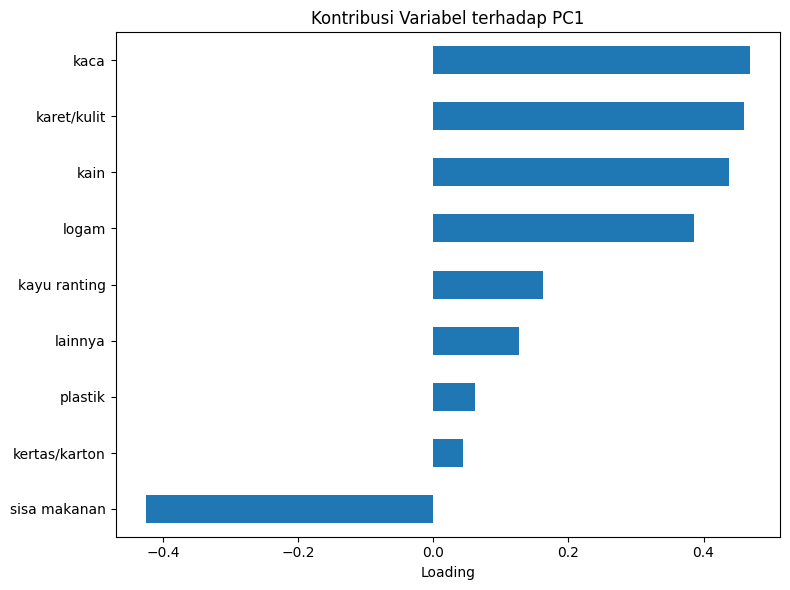

In [409]:
import pandas as pd

loadings = pd.Series(
    pca.components_[0],
    index=komposisi_cols
)

plt.figure(figsize=(8,6))
loadings.sort_values().plot(kind="barh")

plt.title("Kontribusi Variabel terhadap PC1")
plt.xlabel("Loading")
plt.tight_layout()
plt.show()

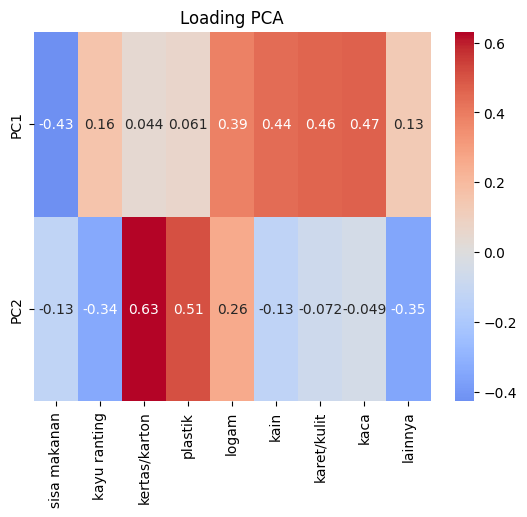

In [407]:
import seaborn as sns

loading_df = pd.DataFrame(
    pca.components_,
    columns=komposisi_cols,
    index=["PC1", "PC2"]
)

sns.heatmap(loading_df, annot=True, cmap="coolwarm", center=0)
plt.title("Loading PCA")
plt.show()

In [412]:
df_komposisi["Provinsi"].unique()

array(['Aceh', 'Sumatera Utara', 'Jawa Barat', 'Kalimantan Tengah',
       'Kalimantan Selatan', 'Sulawesi Utara', 'Sulawesi Tenggara',
       'Gorontalo', 'Sumatera Barat', 'Riau', 'Jambi', 'Sumatera Selatan',
       'Bengkulu', 'Lampung', 'Kepulauan Bangka Belitung',
       'Kepulauan Riau', 'Jawa Tengah', 'Daerah Istimewa Yogyakarta',
       'Jawa Timur', 'Banten', 'Bali', 'Kalimantan Barat',
       'Kalimantan Timur', 'Kalimantan Utara', 'Sulawesi Tengah',
       'Sulawesi Selatan', 'Sulawesi Barat', 'Maluku', 'Maluku Utara',
       'Papua Barat', 'DKI Jakarta', 'Nusa Tenggara Barat', 'Papua',
       'Papua Selatan', 'Papua Barat Daya', 'Nusa Tenggara Timur',
       'Papua Tengah', 'Papua Pegunungan'], dtype=object)

In [436]:
import geopandas as gpd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

gdf_kab = gpd.read_file(
    PROJECT_ROOT / "notebooks" / "shp" / "DUKCAPIL_KAB.shp"
)

gdf_kab["jumlah_pen"].head()


/Users/macbook/MET-pipeline/met/lib/python3.9/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


0    200123
1    153829
2    429143
3     97124
4    234339
Name: jumlah_pen, dtype: int64

In [415]:
df_populasi["provinsi"].unique()

array(['Aceh', 'Sumatera Utara', 'Sumatera Barat', 'Riau', 'Jambi',
       'Sumatera Selatan', 'Bengkulu', 'Lampung',
       'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'DKI Jakarta',
       'Jawa Barat', 'Jawa Tengah', 'DI Yogyakarta', 'Jawa Timur',
       'Banten', 'Bali', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur',
       'Kalimantan Barat', 'Kalimantan Tengah', 'Kalimantan Selatan',
       'Kalimantan Timur', 'Kalimantan Utara', 'Sulawesi Utara',
       'Sulawesi Tengah', 'Sulawesi Selatan', 'Sulawesi Tenggara',
       'Gorontalo', 'Sulawesi Barat', 'Maluku', 'Maluku Utara',
       'Papua Barat', 'Papua Barat Daya', 'Papua', 'Papua Selatan',
       'Papua Tengah', 'Papua Pegunungan', 'Indonesia'], dtype=object)

In [417]:
df_populasi = df_populasi[df_populasi["provinsi"] != "Indonesia"]

In [419]:
df_populasi["provinsi"] = df_populasi["provinsi"].replace({
    "DI Yogyakarta": "Daerah Istimewa Yogyakarta"
})

/var/folders/87/52vrkh1n3fb5vgbxpy9qwrfh0000gn/T/ipykernel_34418/1184439683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_populasi["provinsi"] = df_populasi["provinsi"].replace({


In [428]:
df_komposisi

,Tahun,periode,Provinsi,Kabupaten/Kota,sisa makanan,kayu ranting,kertas/karton,plastik,logam,kain,karet/kulit,kaca,lainnya,Total_Persen,has_report,Deviation,Completeness,Completeness_0_10
0,2019,1,Aceh,Kota Langsa,17.0,20.00,7.00,7.00,12.00,6.00,8.00,5.00,7.0,89.0,True,11.0,0.890,8.90
1,2019,1,Sumatera Utara,Kab. Langkat,22.9,19.90,18.90,14.60,1.00,3.00,2.00,2.00,7.0,91.3,True,8.7,0.913,9.13
2,2019,1,Jawa Barat,Kab. Bandung,42.0,10.00,10.00,20.00,2.00,1.00,NaN,1.00,14.0,100.0,True,0.0,1.000,10.00
3,2019,1,Jawa Barat,Kab. Bekasi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,100.0,0.000,0.00
4,2019,1,Jawa Barat,Kab. Pangandaran,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,100.0,0.000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219,2025,1,Papua,Kota Jayapura,54.0,9.50,5.80,15.79,2.30,3.07,2.05,1.49,6.0,100.0,True,0.0,1.000,10.00
1220,2025,1,Papua Selatan,Kab. Boven Digoel,5.0,5.00,2.00,70.00,1.00,1.00,1.00,1.00,14.0,100.0,True,0.0,1.000,10.00
1221,2025,1,Papua Selatan,Kab. Asmat,23.0,10.00,15.00,30.00,5.00,5.00,5.00,3.00,4.0,100.0,True,0.0,1.000,10.00
1222,2025,1,Papua Tengah,Kab. Mimika,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,100.0,0.000,0.00


In [429]:
df_populasi

,provinsi,jumlah penduduk (ribu),laju pertumbuhan penduduk per tahun,persentase penduduk,kepadatan penduduk per km persegi (km2),rasio jenis kelamin penduduk
0,Aceh,5554.8,1.39,1.97,98,100.9
1,Sumatera Utara,15588.5,1.40,5.54,215,100.8
2,Sumatera Barat,5836.2,1.43,2.07,139,101.5
3,Riau,6728.1,1.37,2.39,75,104.4
4,Jambi,3724.3,1.30,1.32,76,103.4
5,Sumatera Selatan,8837.3,1.15,3.14,102,103.7
6,Bengkulu,2112.2,1.32,0.75,105,104.4
7,Lampung,9419.6,1.20,3.34,281,104.3
8,Kepulauan Bangka Belitung,1531.5,1.36,0.54,92,105.4
9,Kepulauan Riau,2183.3,1.50,0.78,264,103.3


In [430]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ===============================
# SET TAHUN
# ===============================
year = 2024

# ===============================
# FILTER DATA
# ===============================
df_kab = df_komposisi[
    df_komposisi["Tahun"] == year
].copy()

# ===============================
# KOLOM KOMPOSISI
# ===============================
komposisi_cols = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# ===============================
# DROP MISSING
# ===============================
df_kab = df_kab.dropna(subset=komposisi_cols)

# ===============================
# STANDARDIZE
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kab[komposisi_cols])

# ===============================
# KMEANS CLUSTERING
# ===============================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_kab["Cluster"] = kmeans.fit_predict(X_scaled)

# ===============================
# CLUSTER PROFILE (RATA-RATA)
# ===============================
cluster_profile = (
    df_kab
    .groupby("Cluster")[komposisi_cols]
    .mean()
    .round(2)
)

print("Jumlah Kab/Kota per Cluster:")
print(df_kab["Cluster"].value_counts())

print("\nProfil Rata-Rata Komposisi per Cluster:")
print(cluster_profile)

Jumlah Kab/Kota per Cluster:
Cluster
2    124
0     55
1     36
Name: count, dtype: int64

Profil Rata-Rata Komposisi per Cluster:
         sisa makanan  kayu ranting  kertas/karton  plastik  logam  kain  \
Cluster                                                                    
0               25.99         24.25           9.73    23.20   3.07  2.68   
1               21.33         13.24          13.58    19.42   8.21  5.40   
2               49.26          7.58          11.15    17.56   2.03  1.78   

         karet/kulit  kaca  lainnya  
Cluster                              
0               2.25  1.84     5.65  
1               4.42  6.08     7.46  
2               1.28  1.62     5.66  


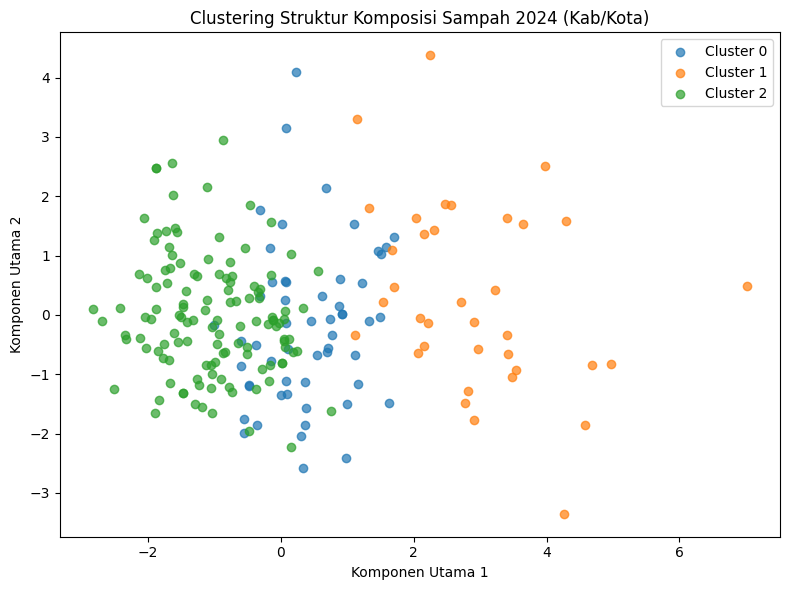

In [431]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ===============================
# SET TAHUN
# ===============================
year = 2024

df_kab = df_komposisi[
    df_komposisi["Tahun"] == year
].copy()

komposisi_cols = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# ===============================
# CLEAN DATA
# ===============================
df_kab = df_kab.dropna(subset=komposisi_cols)

# ===============================
# STANDARDIZE
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kab[komposisi_cols])

# ===============================
# CLUSTERING
# ===============================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_kab["Cluster"] = kmeans.fit_predict(X_scaled)

# ===============================
# PCA FOR VISUALIZATION
# ===============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_kab["PC1"] = X_pca[:, 0]
df_kab["PC2"] = X_pca[:, 1]

# ===============================
# SCATTER PLOT
# ===============================
plt.figure(figsize=(8,6))

for cluster in sorted(df_kab["Cluster"].unique()):
    subset = df_kab[df_kab["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Komponen Utama 1")
plt.ylabel("Komponen Utama 2")
plt.title("Clustering Struktur Komposisi Sampah 2024 (Kab/Kota)")
plt.legend()
plt.tight_layout()
plt.show()

In [437]:
cluster_profile = (
    df_kab
    .groupby("Cluster")[komposisi_cols]
    .mean()
    .round(2)
)

print(cluster_profile)

         sisa makanan  kayu ranting  kertas/karton  plastik  logam  kain  \
Cluster                                                                    
0               25.99         24.25           9.73    23.20   3.07  2.68   
1               21.33         13.24          13.58    19.42   8.21  5.40   
2               49.26          7.58          11.15    17.56   2.03  1.78   

         karet/kulit  kaca  lainnya  
Cluster                              
0               2.25  1.84     5.65  
1               4.42  6.08     7.46  
2               1.28  1.62     5.66  


In [433]:
import geopandas as gpd

gdf_kab = gpd.read_file("notebooks/shp/DUKCAPIL_KAB.shp")

gdf_kab.head()

DataSourceError: notebooks/shp/DUKCAPIL_KAB.shp: No such file or directory

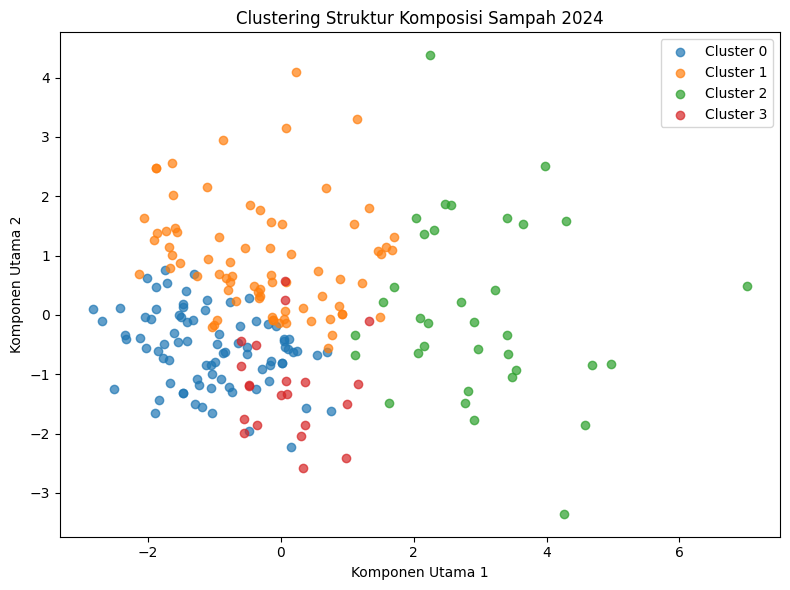


Jumlah Kab/Kota per Cluster:
Cluster
0    83
1    76
2    35
3    21
Name: count, dtype: int64

Profil Rata-Rata Komposisi per Cluster:
         sisa makanan  kayu ranting  kertas/karton  plastik  logam  kain  \
Cluster                                                                    
0               52.08          7.51           8.74    14.46   2.21  2.03   
1               35.62         10.80          14.35    25.56   2.63  2.17   
2               22.02         14.31          12.44    18.60   8.16  5.46   
3               24.04         38.37           7.37    17.09   2.24  1.79   

         karet/kulit  kaca  lainnya  
Cluster                              
0               1.39  1.57     6.72  
1               1.77  1.85     4.46  
2               4.55  6.19     7.37  
3               1.54  1.57     5.97  


In [439]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ===============================
# SET TAHUN
# ===============================
year = 2024

df_kab = df_komposisi[
    df_komposisi["Tahun"] == year
].copy()

komposisi_cols = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# ===============================
# CLEAN DATA
# ===============================
df_kab = df_kab.dropna(subset=komposisi_cols)

# ===============================
# STANDARDIZE
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kab[komposisi_cols])

# ===============================
# CLUSTERING (4 CLUSTERS)
# ===============================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df_kab["Cluster"] = kmeans.fit_predict(X_scaled)

# ===============================
# PCA FOR VISUALIZATION
# ===============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_kab["PC1"] = X_pca[:, 0]
df_kab["PC2"] = X_pca[:, 1]

# ===============================
# SCATTER PLOT
# ===============================
plt.figure(figsize=(8,6))

for cluster in sorted(df_kab["Cluster"].unique()):
    subset = df_kab[df_kab["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Komponen Utama 1")
plt.ylabel("Komponen Utama 2")
plt.title("Clustering Struktur Komposisi Sampah 2024")
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# CLUSTER PROFILE
# ===============================
cluster_profile = (
    df_kab
    .groupby("Cluster")[komposisi_cols]
    .mean()
    .round(2)
)

print("\nJumlah Kab/Kota per Cluster:")
print(df_kab["Cluster"].value_counts())

print("\nProfil Rata-Rata Komposisi per Cluster:")
print(cluster_profile)

In [442]:
df_kab

,Tahun,periode,Provinsi,Kabupaten/Kota,sisa makanan,kayu ranting,kertas/karton,plastik,logam,kain,karet/kulit,kaca,lainnya,Total_Persen,has_report,Deviation,Completeness,Completeness_0_10,Cluster
645,2024,1,Aceh,Kab. Aceh Selatan,30.08,12.29,13.1,16.33,6.4,5.42,3.43,5.35,7.6,100.0,True,0.0,1.0,10.0,2
647,2024,1,Aceh,Kab. Aceh Timur,25.00,21.00,9.0,14.00,6.0,5.00,7.00,8.00,5.0,100.0,True,0.0,1.0,10.0,2
648,2024,1,Aceh,Kab. Aceh Tengah,22.00,18.00,7.0,26.00,3.0,11.00,5.00,5.00,3.0,100.0,True,0.0,1.0,10.0,2
649,2024,1,Aceh,Kab. Aceh Barat,57.00,3.30,6.0,24.00,4.0,3.00,1.00,1.20,0.5,100.0,True,0.0,1.0,10.0,0
650,2024,1,Aceh,Kab. Aceh Besar,25.50,25.50,9.5,21.60,5.1,3.30,3.30,3.70,2.5,100.0,True,0.0,1.0,10.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,2024,1,Papua Barat,Kab. Kaimana,20.00,10.00,10.0,30.00,15.0,5.00,2.00,3.00,5.0,100.0,True,0.0,1.0,10.0,2
969,2024,1,Papua Selatan,Kab. Boven Digoel,5.00,5.00,20.0,60.00,2.0,1.00,1.00,2.00,4.0,100.0,True,0.0,1.0,10.0,1
970,2024,1,Papua Selatan,Kab. Asmat,20.00,11.80,15.0,40.00,4.0,2.40,3.00,1.80,2.0,100.0,True,0.0,1.0,10.0,1
971,2024,1,Papua Tengah,Kab. Nabire,23.00,10.00,8.0,27.00,6.0,5.00,5.00,7.00,9.0,100.0,True,0.0,1.0,10.0,2


In [443]:
gdf_kab

,no_prop,no_kab,kode_prop_,kode_kab_s,jumlah_des,jumlah_kel,nama_prop,nama_kab,jumlah_kec,jumlah_pen,...,nelayan,pelajar_ma,guru,wiraswasta,pengacara,st_area_sh,st_length_,SHAPE__Len,SHAPE__Are,geometry
0,11,5,11,1105,321,0,ACEH,KAB. ACEH BARAT,12,200123,...,2422,50870,921,19138,2,0.226751,2.624683,2.624683,0.226751,"POLYGON Z ((96.26028 4.71238 0, 96.25721 4.707..."
1,11,12,11,1112,152,0,ACEH,KAB. ACEH BARAT DAYA,9,153829,...,2603,33495,751,16825,9,0.153250,2.272465,2.272465,0.153250,"MULTIPOLYGON Z (((96.72918 4.09413 0, 96.73006..."
2,11,6,11,1106,604,0,ACEH,KAB. ACEH BESAR,23,429143,...,2324,115577,3291,26634,40,0.235919,4.668149,4.668149,0.235919,"MULTIPOLYGON Z (((95.43359 5.65658 0, 95.43362..."
3,11,14,11,1114,172,0,ACEH,KAB. ACEH JAYA,9,97124,...,1081,24372,497,10060,0,0.315688,3.392333,3.392333,0.315688,"MULTIPOLYGON Z (((95.38995 5.23068 0, 95.39108..."
4,11,1,11,1101,260,0,ACEH,KAB. ACEH SELATAN,18,234339,...,3505,62384,1303,3313,9,0.339720,4.376483,4.376483,0.339720,"MULTIPOLYGON Z (((97.267 3.64883 0, 97.26747 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,93,4,93,9304,224,0,PAPUA SELATAN,KAB. ASMAT,25,109138,...,1109,15089,388,2393,0,2.041032,10.505102,10.505102,2.041032,"MULTIPOLYGON Z (((137.87769 -4.57276 0, 137.87..."
510,93,2,93,9302,112,0,PAPUA SELATAN,KAB. BOVEN DIGOEL,20,66688,...,23,11864,286,3352,0,1.924223,9.410012,9.410012,1.924223,"POLYGON Z ((141.00075 -5.169 0, 141.00073 -5.1..."
511,93,3,93,9303,162,2,PAPUA SELATAN,KAB. MAPPI,15,108467,...,240,19248,548,2379,0,1.983579,8.975131,8.975131,1.983579,"MULTIPOLYGON Z (((139.81656 -5.58206 0, 139.71..."
512,93,1,93,9301,179,11,PAPUA SELATAN,KAB. MERAUKE,22,238551,...,1967,40083,1042,12475,8,3.690520,19.473893,19.473893,3.690520,"MULTIPOLYGON Z (((140.8546 -6.61816 0, 140.855..."


In [445]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ===============================
# LOAD POPULATION FROM SHAPEFILE
# ===============================
gdf_kab = gpd.read_file(PROJECT_ROOT / "notebooks" / "shp" / "DUKCAPIL_KAB.shp")

pop_kab = gdf_kab[["nama_kab", "jumlah_pen"]].copy()
pop_kab = pop_kab.rename(columns={
    "nama_kab": "kabkota",
    "jumlah_pen": "Population"
})

# ===============================
# FILTER KOMPOSISI 2024
# ===============================
year = 2024

df_kab = df_komposisi[
    df_komposisi["Tahun"] == year
].copy()

komposisi_cols = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# ===============================
# CLEAN DATA
# ===============================
df_kab = df_kab.dropna(subset=komposisi_cols)

# ===============================
# STANDARDIZE
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kab[komposisi_cols])

# ===============================
# CLUSTERING (4 CLUSTERS)
# ===============================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df_kab["Cluster"] = kmeans.fit_predict(X_scaled)

# ===============================
# MERGE POPULATION (AFTER CLUSTER)
# ===============================
df_kab = df_kab.merge(
    pop_kab,
    on="kabkota",
    how="left"
)

print("Missing population:", df_kab["Population"].isna().sum())

# ===============================
# CLUSTER PROFILE (STRUCTURE)
# ===============================
cluster_profile = (
    df_kab
    .groupby("Cluster")[komposisi_cols]
    .mean()
    .round(2)
)

print("\nJumlah Kab/Kota per Cluster:")
print(df_kab["Cluster"].value_counts())

print("\nProfil Rata-Rata Komposisi per Cluster:")
print(cluster_profile)

# ===============================
# POPULATION SUMMARY PER CLUSTER
# ===============================
cluster_population_summary = (
    df_kab
    .groupby("Cluster")["Population"]
    .agg(["mean", "median", "min", "max"])
    .round(0)
)

print("\nRingkasan Populasi per Cluster:")
print(cluster_population_summary)

# ===============================
# PCA FOR VISUALIZATION
# ===============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_kab["PC1"] = X_pca[:, 0]
df_kab["PC2"] = X_pca[:, 1]

# ===============================
# SCATTER PLOT
# ===============================
plt.figure(figsize=(8,6))

for cluster in sorted(df_kab["Cluster"].unique()):
    subset = df_kab[df_kab["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Komponen Utama 1")
plt.ylabel("Komponen Utama 2")
plt.title("Clustering Struktur Komposisi Sampah 2024 (4 Cluster)")
plt.legend()
plt.tight_layout()
plt.show()

/Users/macbook/MET-pipeline/met/lib/python3.9/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


KeyError: 'kabkota'

In [446]:
df_kab

,Tahun,periode,Provinsi,Kabupaten/Kota,sisa makanan,kayu ranting,kertas/karton,plastik,logam,kain,karet/kulit,kaca,lainnya,Total_Persen,has_report,Deviation,Completeness,Completeness_0_10,Cluster
645,2024,1,Aceh,Kab. Aceh Selatan,30.08,12.29,13.1,16.33,6.4,5.42,3.43,5.35,7.6,100.0,True,0.0,1.0,10.0,2
647,2024,1,Aceh,Kab. Aceh Timur,25.00,21.00,9.0,14.00,6.0,5.00,7.00,8.00,5.0,100.0,True,0.0,1.0,10.0,2
648,2024,1,Aceh,Kab. Aceh Tengah,22.00,18.00,7.0,26.00,3.0,11.00,5.00,5.00,3.0,100.0,True,0.0,1.0,10.0,2
649,2024,1,Aceh,Kab. Aceh Barat,57.00,3.30,6.0,24.00,4.0,3.00,1.00,1.20,0.5,100.0,True,0.0,1.0,10.0,0
650,2024,1,Aceh,Kab. Aceh Besar,25.50,25.50,9.5,21.60,5.1,3.30,3.30,3.70,2.5,100.0,True,0.0,1.0,10.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,2024,1,Papua Barat,Kab. Kaimana,20.00,10.00,10.0,30.00,15.0,5.00,2.00,3.00,5.0,100.0,True,0.0,1.0,10.0,2
969,2024,1,Papua Selatan,Kab. Boven Digoel,5.00,5.00,20.0,60.00,2.0,1.00,1.00,2.00,4.0,100.0,True,0.0,1.0,10.0,1
970,2024,1,Papua Selatan,Kab. Asmat,20.00,11.80,15.0,40.00,4.0,2.40,3.00,1.80,2.0,100.0,True,0.0,1.0,10.0,1
971,2024,1,Papua Tengah,Kab. Nabire,23.00,10.00,8.0,27.00,6.0,5.00,5.00,7.00,9.0,100.0,True,0.0,1.0,10.0,2


In [450]:
pop_kab

,kabkota,Population
0,KAB. ACEH BARAT,200123
1,KAB. ACEH BARAT DAYA,153829
2,KAB. ACEH BESAR,429143
3,KAB. ACEH JAYA,97124
4,KAB. ACEH SELATAN,234339
...,...,...
509,KAB. ASMAT,109138
510,KAB. BOVEN DIGOEL,66688
511,KAB. MAPPI,108467
512,KAB. MERAUKE,238551


In [451]:
gdf_kab

,no_prop,no_kab,kode_prop_,kode_kab_s,jumlah_des,jumlah_kel,nama_prop,nama_kab,jumlah_kec,jumlah_pen,...,nelayan,pelajar_ma,guru,wiraswasta,pengacara,st_area_sh,st_length_,SHAPE__Len,SHAPE__Are,geometry
0,11,5,11,1105,321,0,ACEH,KAB. ACEH BARAT,12,200123,...,2422,50870,921,19138,2,0.226751,2.624683,2.624683,0.226751,"POLYGON Z ((96.26028 4.71238 0, 96.25721 4.707..."
1,11,12,11,1112,152,0,ACEH,KAB. ACEH BARAT DAYA,9,153829,...,2603,33495,751,16825,9,0.153250,2.272465,2.272465,0.153250,"MULTIPOLYGON Z (((96.72918 4.09413 0, 96.73006..."
2,11,6,11,1106,604,0,ACEH,KAB. ACEH BESAR,23,429143,...,2324,115577,3291,26634,40,0.235919,4.668149,4.668149,0.235919,"MULTIPOLYGON Z (((95.43359 5.65658 0, 95.43362..."
3,11,14,11,1114,172,0,ACEH,KAB. ACEH JAYA,9,97124,...,1081,24372,497,10060,0,0.315688,3.392333,3.392333,0.315688,"MULTIPOLYGON Z (((95.38995 5.23068 0, 95.39108..."
4,11,1,11,1101,260,0,ACEH,KAB. ACEH SELATAN,18,234339,...,3505,62384,1303,3313,9,0.339720,4.376483,4.376483,0.339720,"MULTIPOLYGON Z (((97.267 3.64883 0, 97.26747 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,93,4,93,9304,224,0,PAPUA SELATAN,KAB. ASMAT,25,109138,...,1109,15089,388,2393,0,2.041032,10.505102,10.505102,2.041032,"MULTIPOLYGON Z (((137.87769 -4.57276 0, 137.87..."
510,93,2,93,9302,112,0,PAPUA SELATAN,KAB. BOVEN DIGOEL,20,66688,...,23,11864,286,3352,0,1.924223,9.410012,9.410012,1.924223,"POLYGON Z ((141.00075 -5.169 0, 141.00073 -5.1..."
511,93,3,93,9303,162,2,PAPUA SELATAN,KAB. MAPPI,15,108467,...,240,19248,548,2379,0,1.983579,8.975131,8.975131,1.983579,"MULTIPOLYGON Z (((139.81656 -5.58206 0, 139.71..."
512,93,1,93,9301,179,11,PAPUA SELATAN,KAB. MERAUKE,22,238551,...,1967,40083,1042,12475,8,3.690520,19.473893,19.473893,3.690520,"MULTIPOLYGON Z (((140.8546 -6.61816 0, 140.855..."


In [452]:
print(gdf_kab.columns)

Index(['no_prop', 'no_kab', 'kode_prop_', 'kode_kab_s', 'jumlah_des',
       'jumlah_kel', 'nama_prop', 'nama_kab', 'jumlah_kec', 'jumlah_pen',
       ...
       'nelayan', 'pelajar_ma', 'guru', 'wiraswasta', 'pengacara',
       'st_area_sh', 'st_length_', 'SHAPE__Len', 'SHAPE__Are', 'geometry'],
      dtype='object', length=105)


/Users/macbook/MET-pipeline/met/lib/python3.9/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


Missing population: 1

Jumlah Kab/Kota per Cluster:
Cluster
0    83
1    76
2    35
3    21
Name: count, dtype: int64

Profil Rata-Rata Komposisi per Cluster:
         sisa makanan  kayu ranting  kertas/karton  plastik  logam  kain  \
Cluster                                                                    
0               52.08          7.51           8.74    14.46   2.21  2.03   
1               35.62         10.80          14.35    25.56   2.63  2.17   
2               22.02         14.31          12.44    18.60   8.16  5.46   
3               24.04         38.37           7.37    17.09   2.24  1.79   

         karet/kulit  kaca  lainnya  
Cluster                              
0               1.39  1.57     6.72  
1               1.77  1.85     4.46  
2               4.55  6.19     7.37  
3               1.54  1.57     5.97  

Ringkasan Populasi per Cluster:
             mean    median      min        max
Cluster                                        
0        584617.0  356875.0

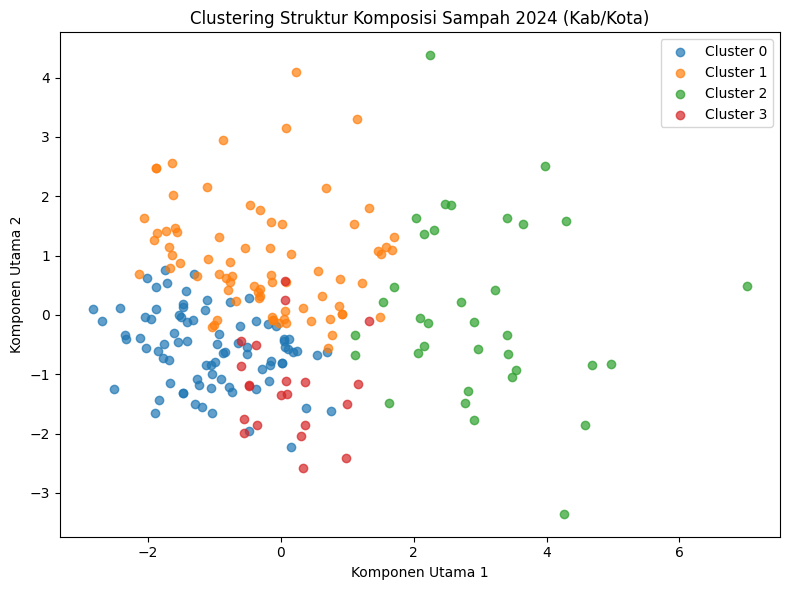

In [453]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ===============================
# LOAD POPULATION SHAPEFILE
# ===============================
gdf_kab = gpd.read_file(PROJECT_ROOT / "notebooks" / "shp" / "DUKCAPIL_KAB.shp")

pop_kab = gdf_kab[["nama_kab", "jumlah_pen"]].copy()
pop_kab = pop_kab.rename(columns={
    "nama_kab": "kabkota",
    "jumlah_pen": "Population"
})

# Normalize population names
pop_kab["kabkota"] = (
    pop_kab["kabkota"]
    .str.upper()
    .str.strip()
)

# ===============================
# FILTER KOMPOSISI 2024
# ===============================
year = 2024

df_kab = df_komposisi[
    df_komposisi["Tahun"] == year
].copy()

komposisi_cols = [
    "sisa makanan",
    "kayu ranting",
    "kertas/karton",
    "plastik",
    "logam",
    "kain",
    "karet/kulit",
    "kaca",
    "lainnya"
]

# Clean missing
df_kab = df_kab.dropna(subset=komposisi_cols)

# ===============================
# STANDARDIZE KOMPOSISI
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kab[komposisi_cols])

# ===============================
# CLUSTERING (4 CLUSTERS)
# ===============================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df_kab["Cluster"] = kmeans.fit_predict(X_scaled)

# ===============================
# NORMALIZE NAME BEFORE MERGE
# ===============================
df_kab["Kabupaten/Kota"] = (
    df_kab["Kabupaten/Kota"]
    .str.upper()
    .str.strip()
)

# ===============================
# MERGE POPULATION
# ===============================
df_kab = df_kab.merge(
    pop_kab,
    left_on="Kabupaten/Kota",
    right_on="kabkota",
    how="left"
)

print("Missing population:", df_kab["Population"].isna().sum())

# Drop duplicate key column
df_kab = df_kab.drop(columns=["kabkota"])

# ===============================
# CLUSTER PROFILE
# ===============================
cluster_profile = (
    df_kab
    .groupby("Cluster")[komposisi_cols]
    .mean()
    .round(2)
)

print("\nJumlah Kab/Kota per Cluster:")
print(df_kab["Cluster"].value_counts())

print("\nProfil Rata-Rata Komposisi per Cluster:")
print(cluster_profile)

# ===============================
# POPULATION SUMMARY PER CLUSTER
# ===============================
cluster_population_summary = (
    df_kab
    .groupby("Cluster")["Population"]
    .agg(["mean", "median", "min", "max"])
    .round(0)
)

print("\nRingkasan Populasi per Cluster:")
print(cluster_population_summary)

# ===============================
# PCA VISUALIZATION
# ===============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_kab["PC1"] = X_pca[:, 0]
df_kab["PC2"] = X_pca[:, 1]

plt.figure(figsize=(8,6))

for cluster in sorted(df_kab["Cluster"].unique()):
    subset = df_kab[df_kab["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Komponen Utama 1")
plt.ylabel("Komponen Utama 2")
plt.title("Clustering Struktur Komposisi Sampah 2024 (Kab/Kota)")
plt.legend()
plt.tight_layout()
plt.show()

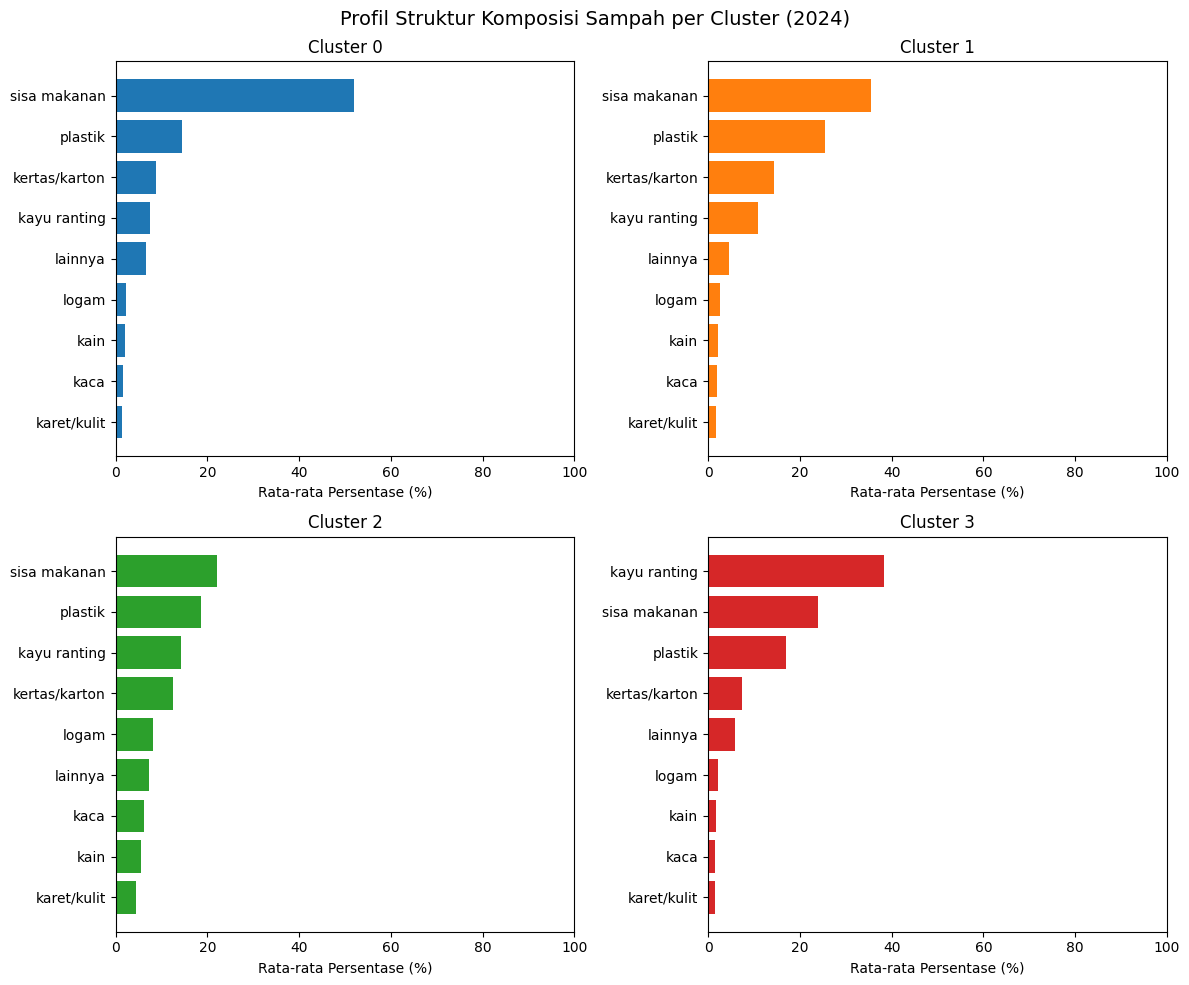

In [461]:
import matplotlib.pyplot as plt

# Hitung rata-rata persentase per cluster
cluster_profile = (
    df_kab
    .groupby("Cluster")[komposisi_cols]
    .mean()
)

# Warna yang sama seperti scatterplot
cluster_colors = {
    0: "#1f77b4",  # biru
    1: "#ff7f0e",  # oranye
    2: "#2ca02c",  # hijau
    3: "#d62728"   # merah
}

clusters = sorted(cluster_profile.index)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    
    profile = cluster_profile.loc[cluster].sort_values(ascending=True)
    
    axes[i].barh(
        profile.index,
        profile.values,
        color=cluster_colors.get(cluster, "gray")
    )
    
    axes[i].set_title(f"Cluster {cluster}")
    axes[i].set_xlim(0, 100)
    axes[i].set_xlabel("Rata-rata Persentase (%)")

plt.suptitle("Profil Struktur Komposisi Sampah per Cluster (2024)", fontsize=14)
plt.tight_layout()
plt.show()

In [462]:
#update meeting
cluster_colors = {
    0: "#1f77b4",  # biru
    1: "#ff7f0e",  # oranye
    2: "#2ca02c",  # hijau
    3: "#d62728"   # merah
}